# eDNA Metabarcoding Pipeline Analysis: Lake Geneva Water
### isONclust3 Clustering Pipeline (Q15 Filter)
**Databases:** PR2 (18S) + MIDORI2 (COI)

**Project:** Genorobotics Semester Project (EPFL)  
**Dataset:** Water eDNA from Lake Geneva  
**Pipeline:** ONT metabarcoding with isONclust3 + SPOA consensus  
**Run date:** May 29, 2026

In [1]:
from scripts.notebook_utils import *
from pathlib import Path

setup_style()

BASE = Path('out/Water_eDNA_18S_COI_14_01_26')
MARKERS = ['18S', 'COI']

In [2]:
# Load taxonomy data
df_18s = pd.read_csv(BASE / 'taxonomy_summary/18S/pr2/comprehensive_taxonomy_18S.csv')
df_coi_raw = pd.read_csv(BASE / 'taxonomy_summary/COI/midori2/comprehensive_taxonomy_COI.csv')

prefix_18s = get_tax_prefix(df_18s)
prefix_coi = get_tax_prefix(df_coi_raw)

print_data_summary(df_18s, '18S', prefix_18s)
print_data_summary(df_coi_raw, 'COI', prefix_coi)
display(df_18s.head(3))
display(df_coi_raw.head(3))


  18S (PR2 database)  -  142 OTUs x 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank', 'Sample_unclassified']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15']
Taxonomy columns:  ['PR2_Domain', 'PR2_Domain_Conf', 'PR2_Phylum', 'PR2_Phylum_Conf', 'PR2_Class', 'PR2_Class_Conf', 'PR2_Order', 'PR2_Order_Conf', 'PR2_Family', 'PR2_Family_Conf', 'PR2_Genus', 'PR2_Genus_Conf', 'PR2_Species', 'PR2_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

  COI (MIDORI2 database)  -  159 OTUs x 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank', 'Sample_unclassified']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sam

,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,PR2_Order_Conf,PR2_Family,PR2_Family_Conf,PR2_Genus,PR2_Genus_Conf,PR2_Species,PR2_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_18S_000085,12.181204,1,0.450884,0.863064,0.866109,0.848699,0.0,0.0,0.942283,...,0.92,Pelagostrombidiidae,0.89,Pelagostrombidiidae,0.88,Pelagostrombidiidae_X,0.88,NaN,NaN,NaN
1,OTU_18S_000063,1.578325,2,0.539807,0.132791,0.118226,0.146274,0.0,0.0,0.051696,...,0.97,Branchiopoda,0.96,Daphnia,0.69,Daphnia_pulex,0.65,NaN,NaN,NaN
2,OTU_18S_000020,0.048544,3,0.000797,0.000638,0.003387,0.000477,0.0,0.0,0.001904,...,0.75,Cryptomonadales_X:nucl,0.75,Plagioselmis:nucl,0.64,Plagioselmis_lacustris:nucl,0.64,NaN,NaN,NaN


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,MIDORI2_Order_Conf,MIDORI2_Family,MIDORI2_Family_Conf,MIDORI2_Genus,MIDORI2_Genus_Conf,MIDORI2_Species,MIDORI2_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_COI_000107,0.728670,1,0.0,0.0,0.0,0.0,0.443306,0.212783,0.0,...,0.07,Lampyridae,0.02,Lamprigera,0.01,Lamprigera,0.01,NaN,NaN,NaN
1,OTU_COI_000160,0.457353,2,0.0,0.0,0.0,0.0,0.260303,0.108340,0.0,...,0.06,Cicadidae,0.02,Neotibicen,0.01,Neotibicen,0.01,NaN,NaN,NaN
2,OTU_COI_000009,0.359197,3,0.0,0.0,0.0,0.0,0.080326,0.254677,0.0,...,1.00,Daphniidae,1.00,Daphnia,1.00,Daphnia,1.00,NaN,NaN,NaN


## 0. Pipeline Overview & Key Changes

**Pipeline steps:**
1. Preprocessing (quality filter Q>=15, length filter)
2. Marker classification (minimap2 against reference amplicons)
2b. Primer trimming (cutadapt — validates amplicon identity)
3. Clustering (isONclust3 + SPOA consensus)
3b. Chimera removal (VSEARCH uchime_denovo with size annotations)
4. Abundance matrix generation
5. Taxonomy assignment (VSEARCH SINTAX, confidence >= 0.8)
6. BLAST validation (top OTUs vs NCBI)
7. Comprehensive summary

### Results (May 29, 2026)
| Marker | Raw Clusters | Chimeras | Clean OTUs |
|--------|:---:|:---:|:---:|
| 18S | 148 | 6 (4.1%) | **142** |
| COI | 262 | 29 (11.1%) | **195** |

- 16 samples (barcodes): 13 → 18S, 2 → COI, 1 negative control
- Total reads: 242,625 → 213,946 kept (11.8% discarded at primer step)

## Confidence Distribution Dashboard

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


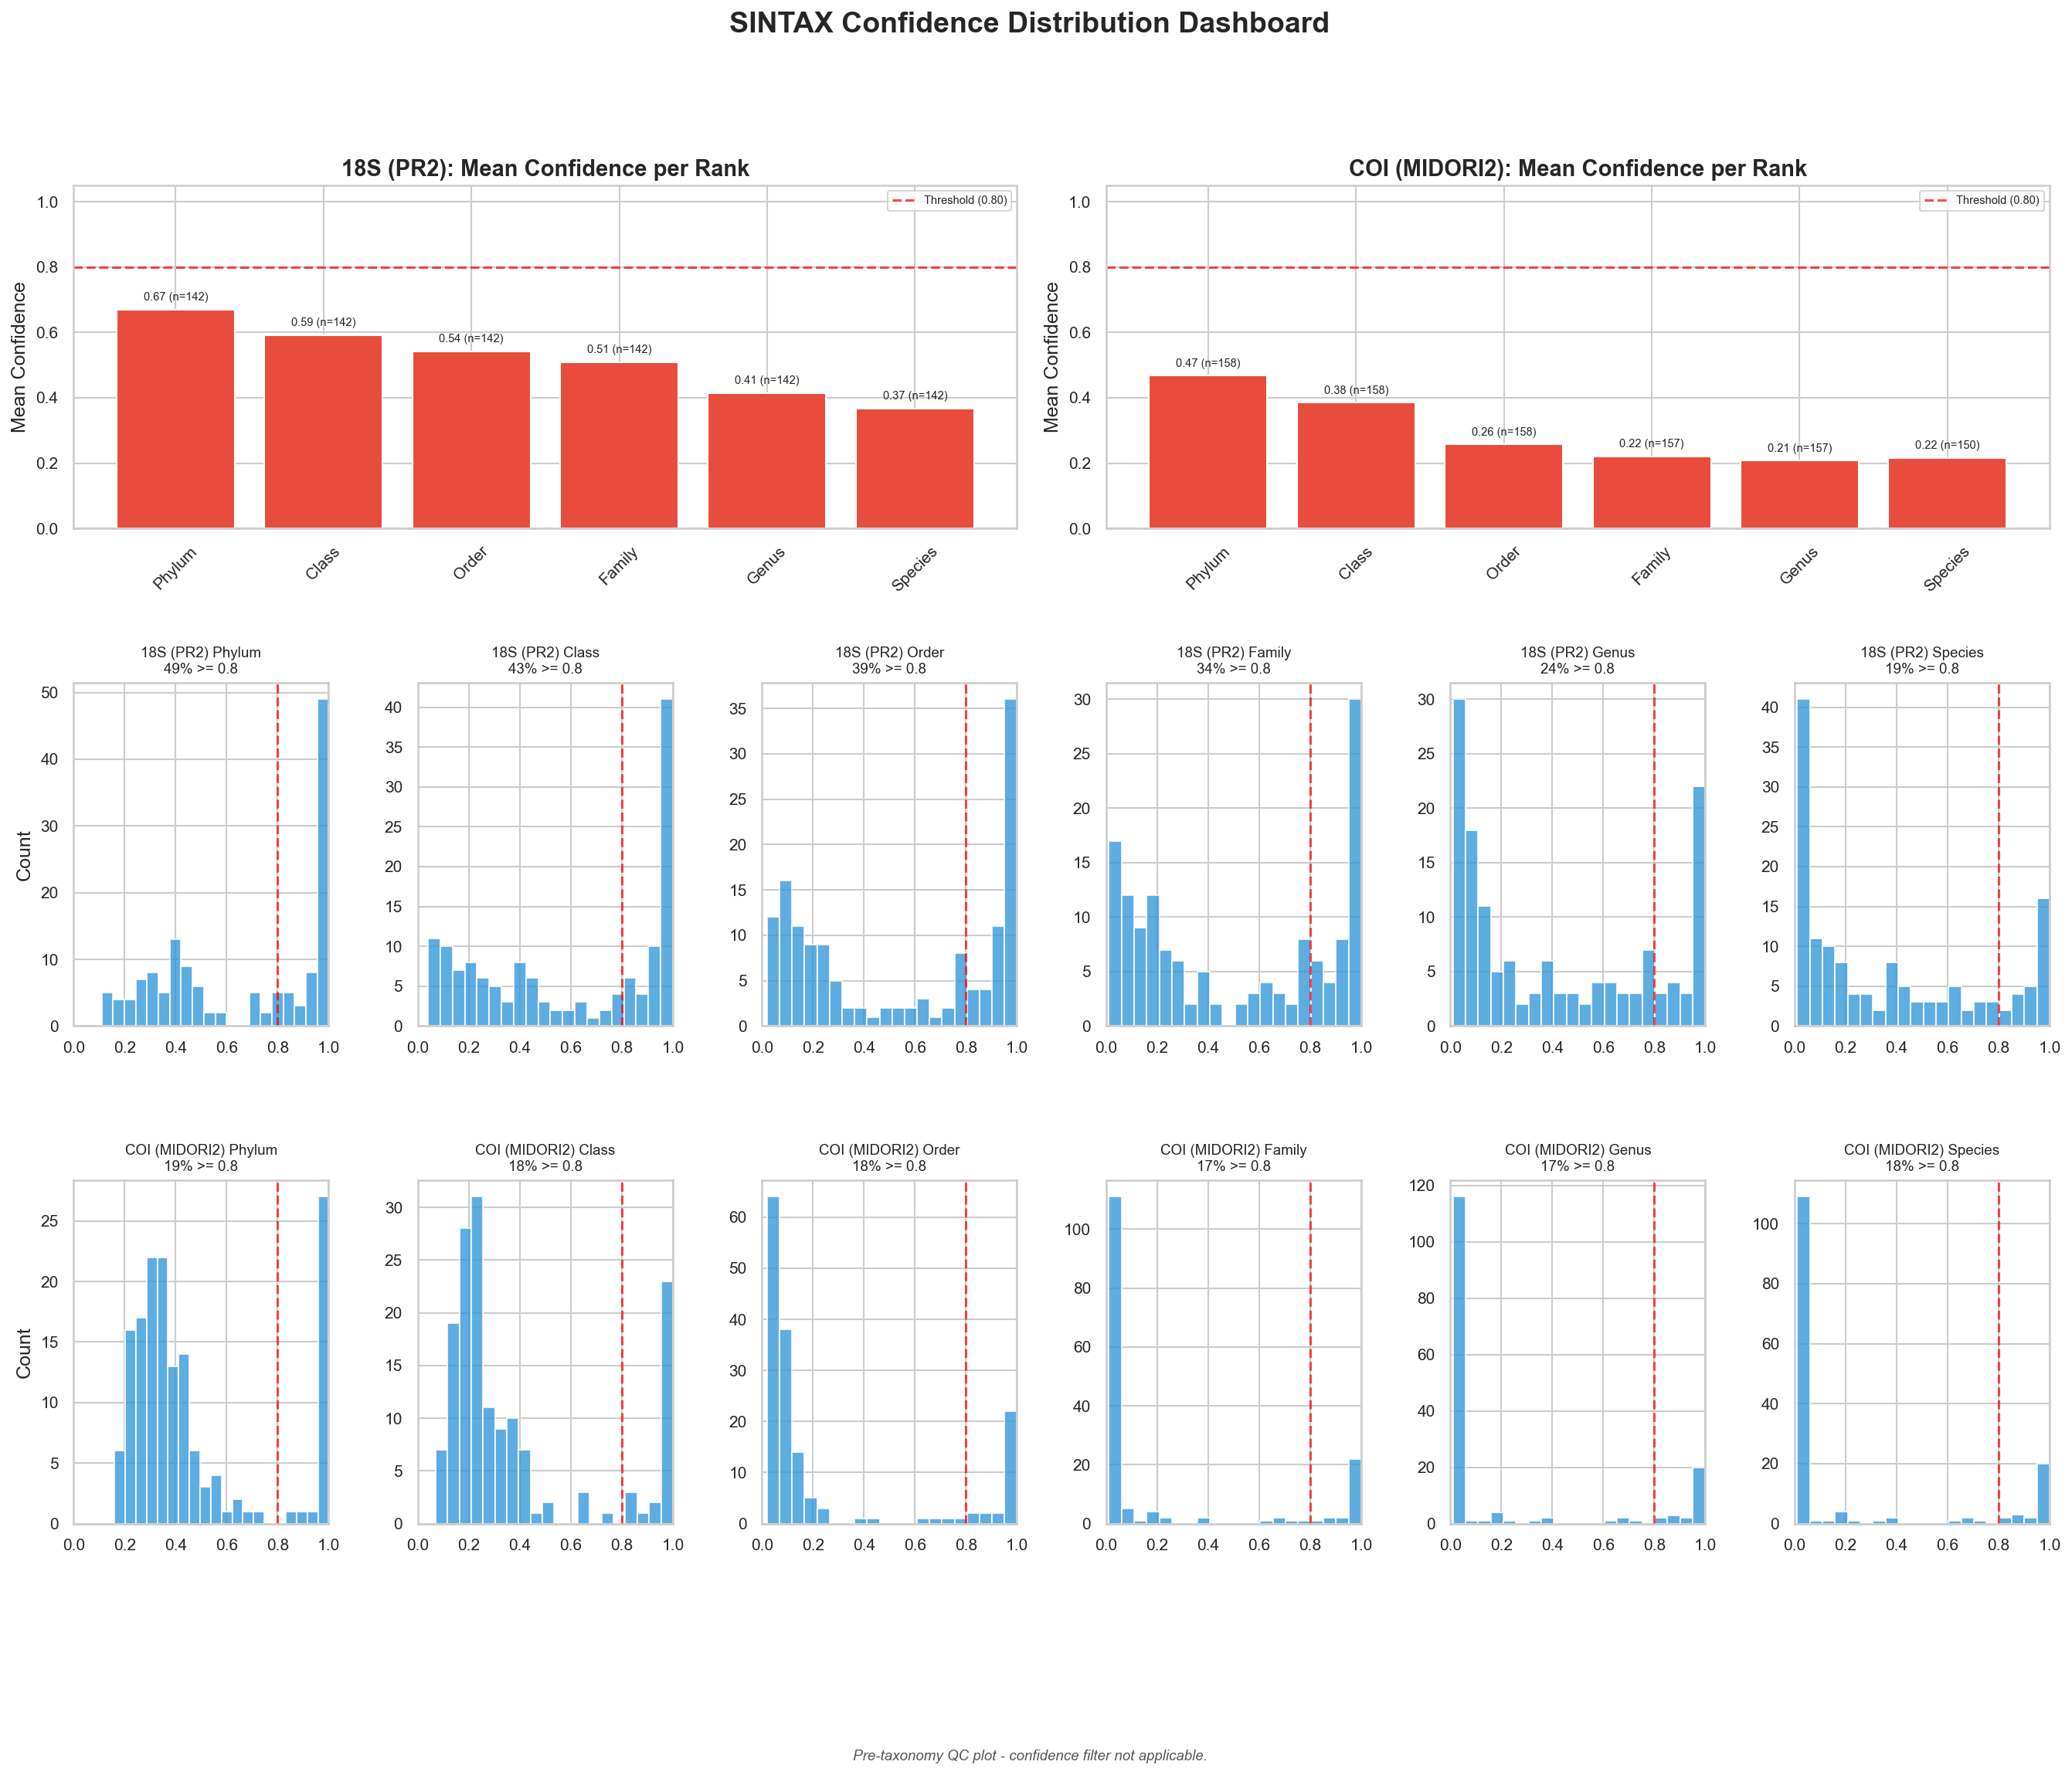

In [3]:
confidence_dashboard([
    (df_18s, prefix_18s, f'18S ({prefix_18s})'),
    (df_coi_raw, prefix_coi, f'COI ({prefix_coi})')
])

## Database Performance Dashboard
Evaluate how well the reference database classifies our OTUs:
- Assignment rate per rank (any vs confident)
- Read-weighted coverage
- Resolution depth (how far down taxonomy we can resolve)

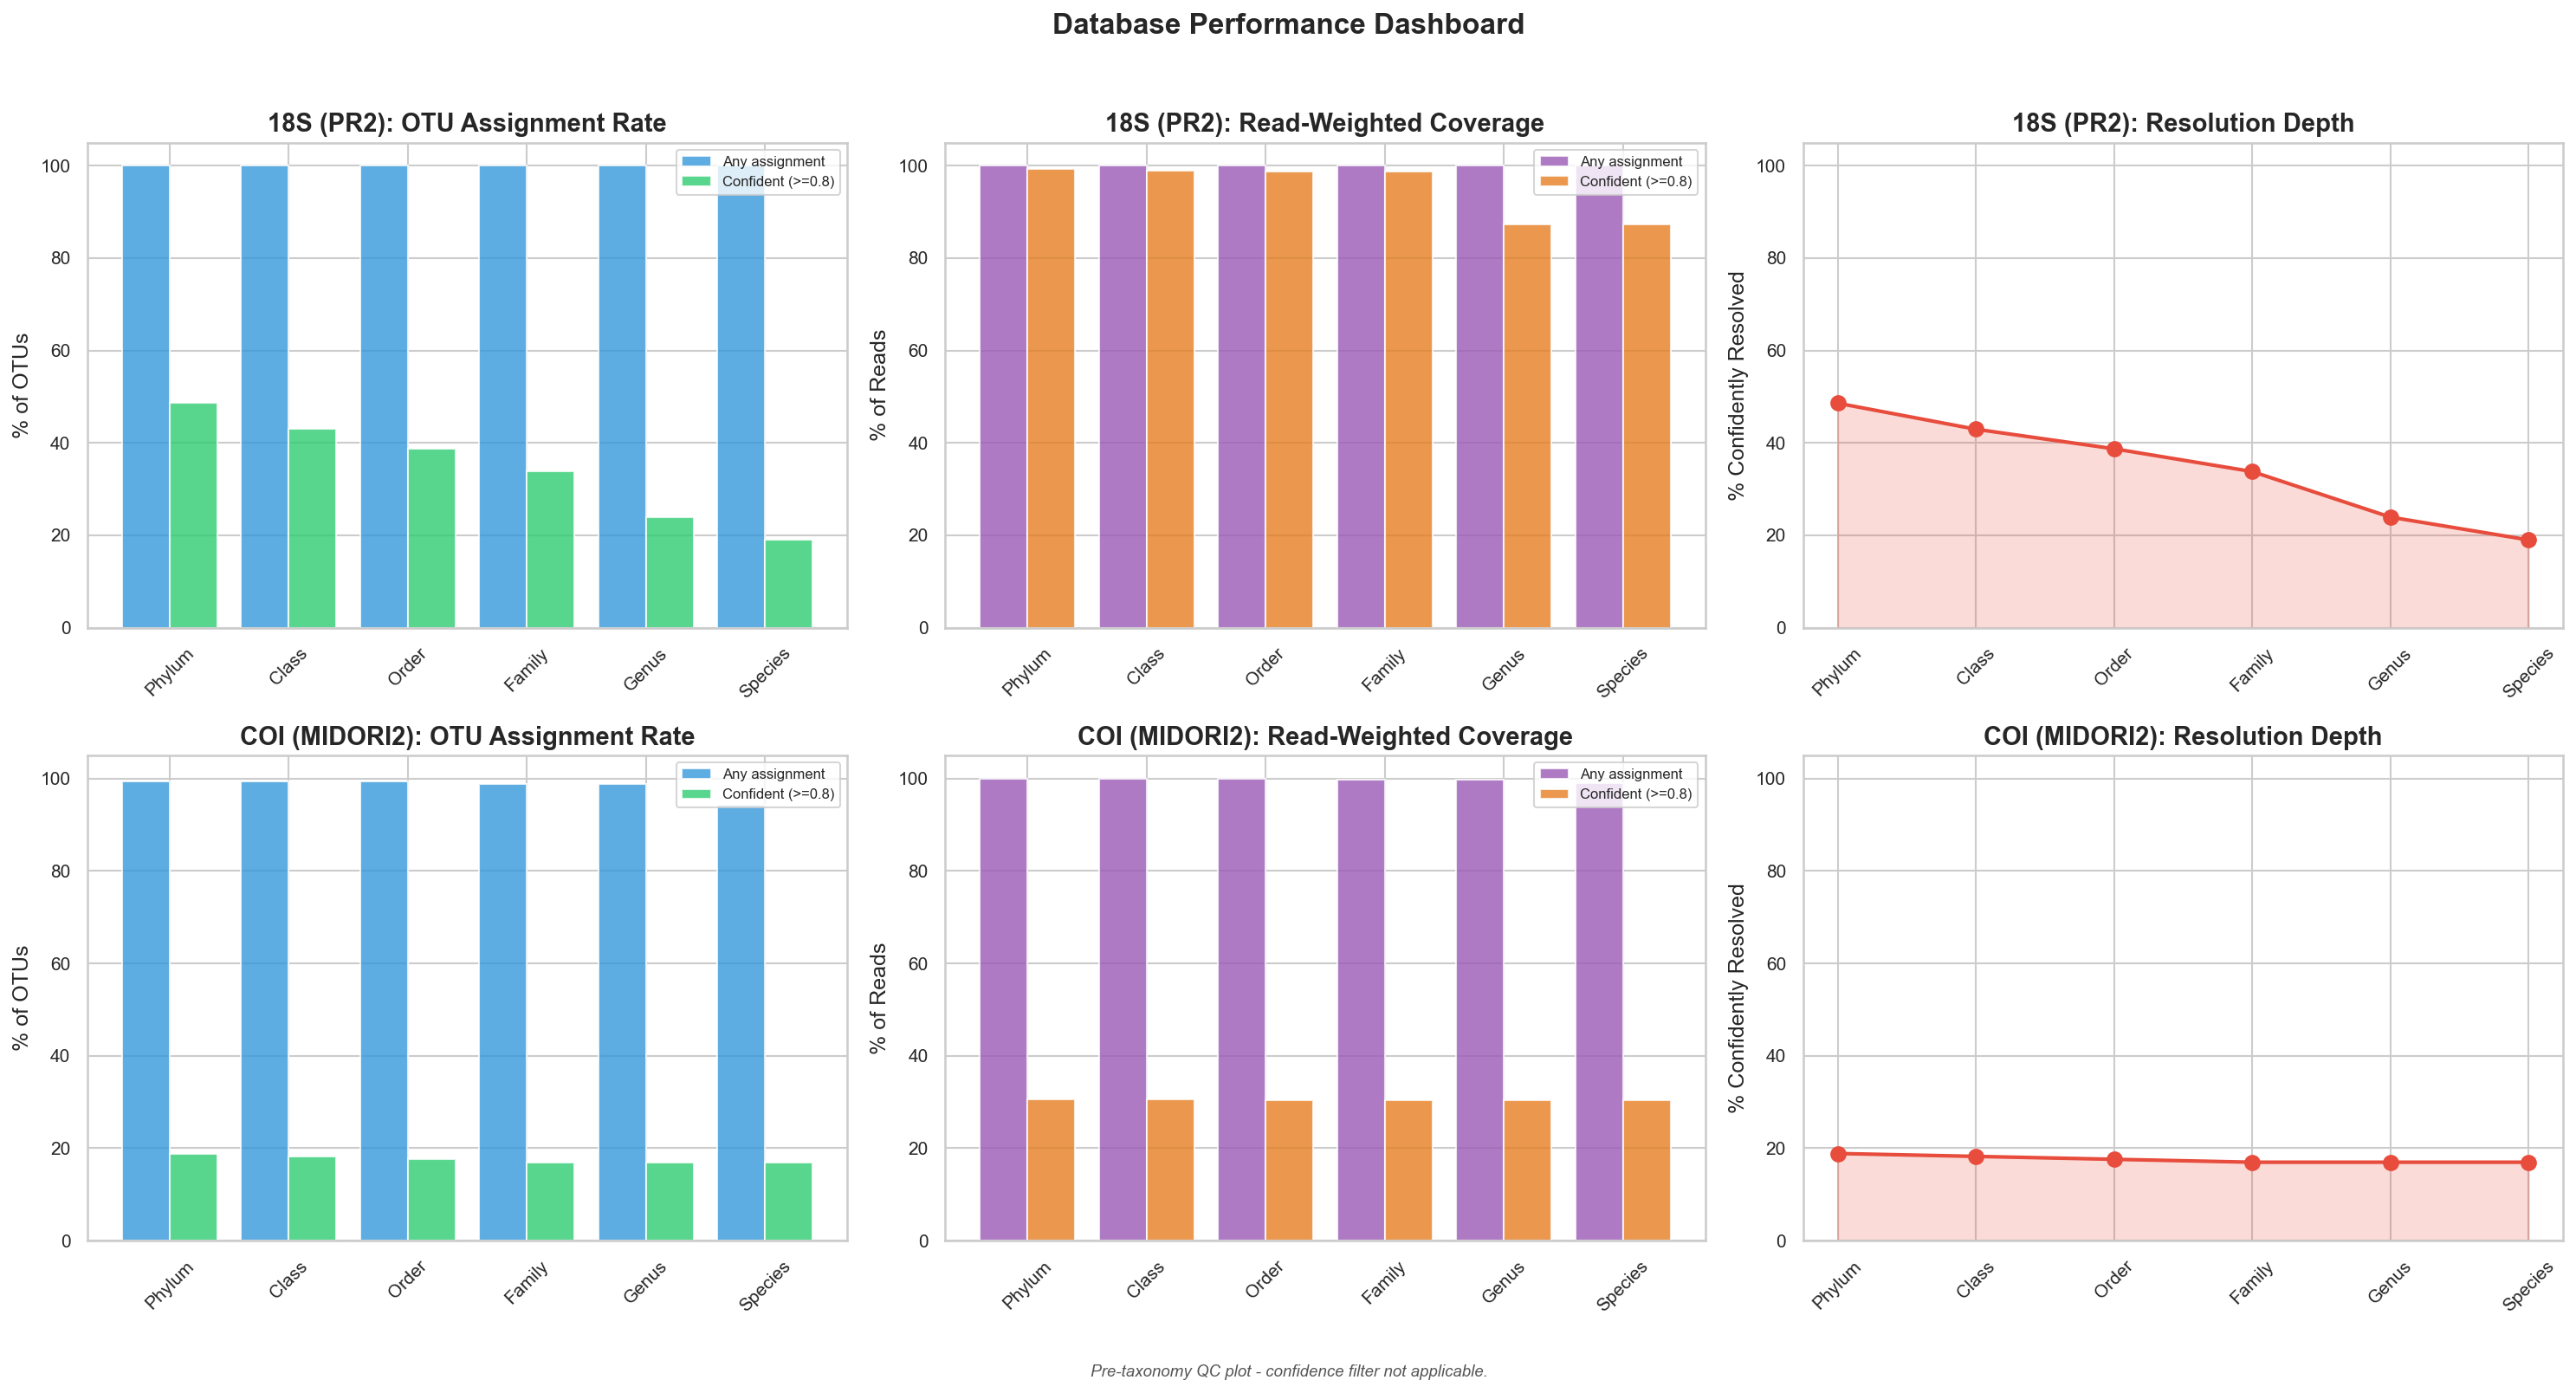

In [4]:
db_performance_dashboard([
    (df_18s, prefix_18s, f'18S ({prefix_18s})'),
    (df_coi_raw, prefix_coi, f'COI ({prefix_coi})')
])

## Raw Read Length Distributions (Pre-Clustering)
Sequence lengths before clustering — reveals expected amplicon sizes and any off-target.

✓ 18S: 204,134 reads, median=1779bp, range=15-3485bp
✓ COI: 9,812 reads, median=754bp, range=400-2218bp


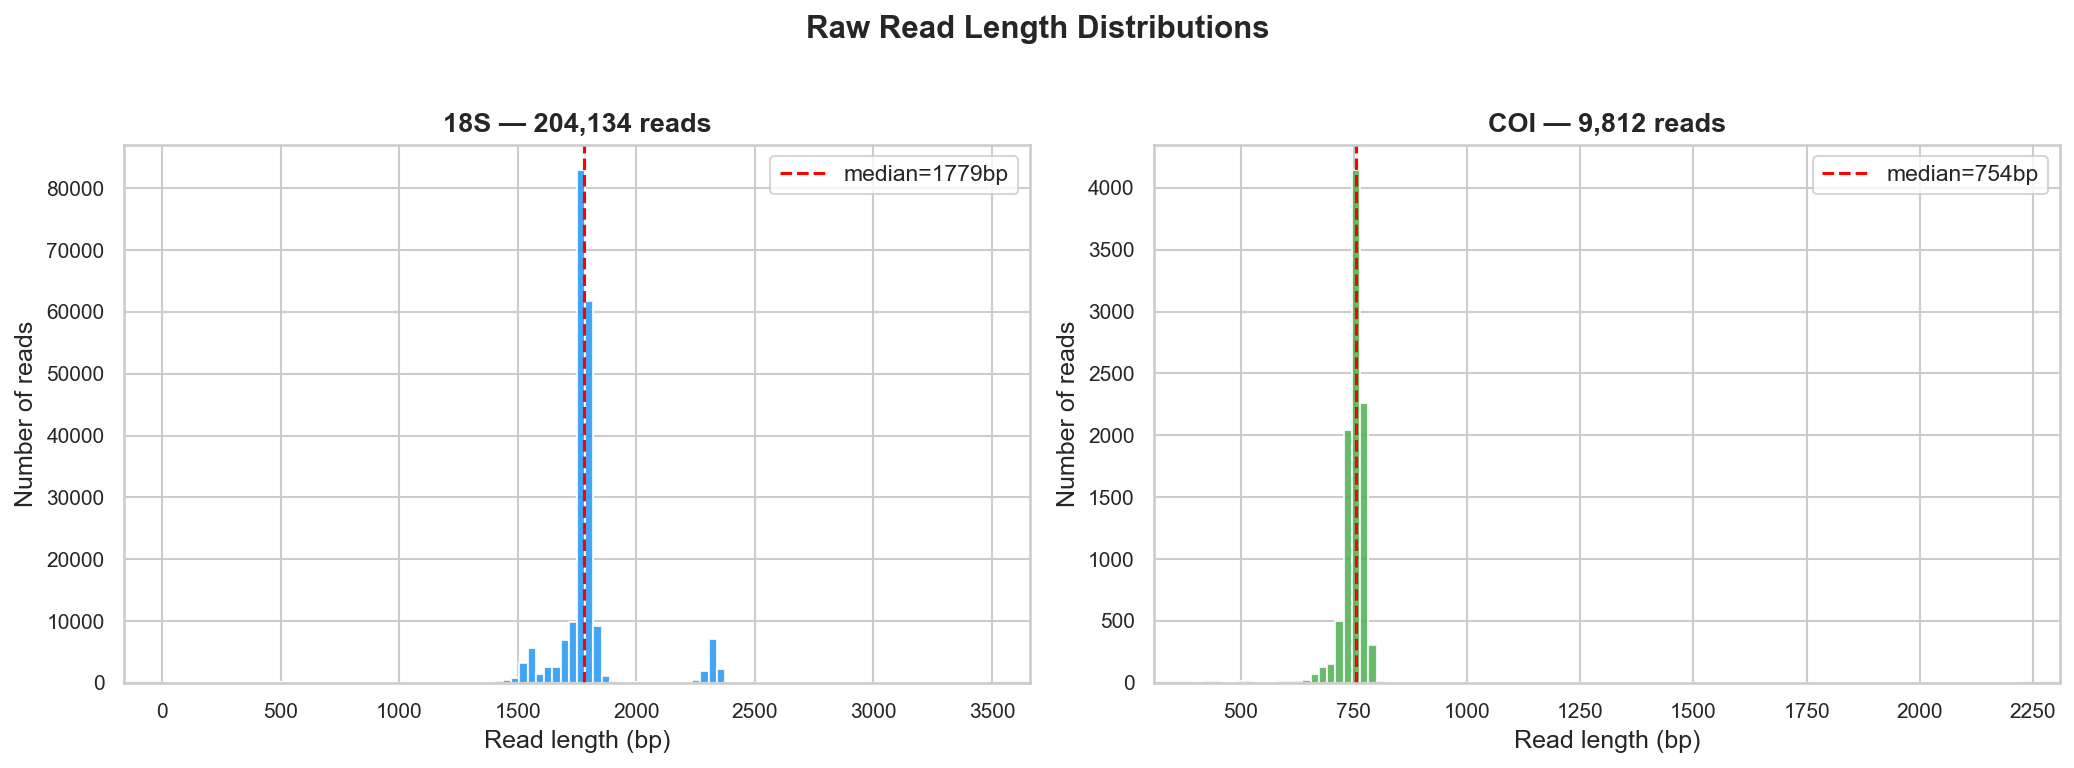

In [5]:
plot_read_lengths(BASE, MARKERS)

## Consensus OTU Sequence Length Distributions
Length of final consensus OTUs — should cluster around expected amplicon size.

✓ 18S: 142 OTUs, median=1970bp, range=396-3676bp
✓ COI: 158 OTUs, median=804bp, range=588-2168bp


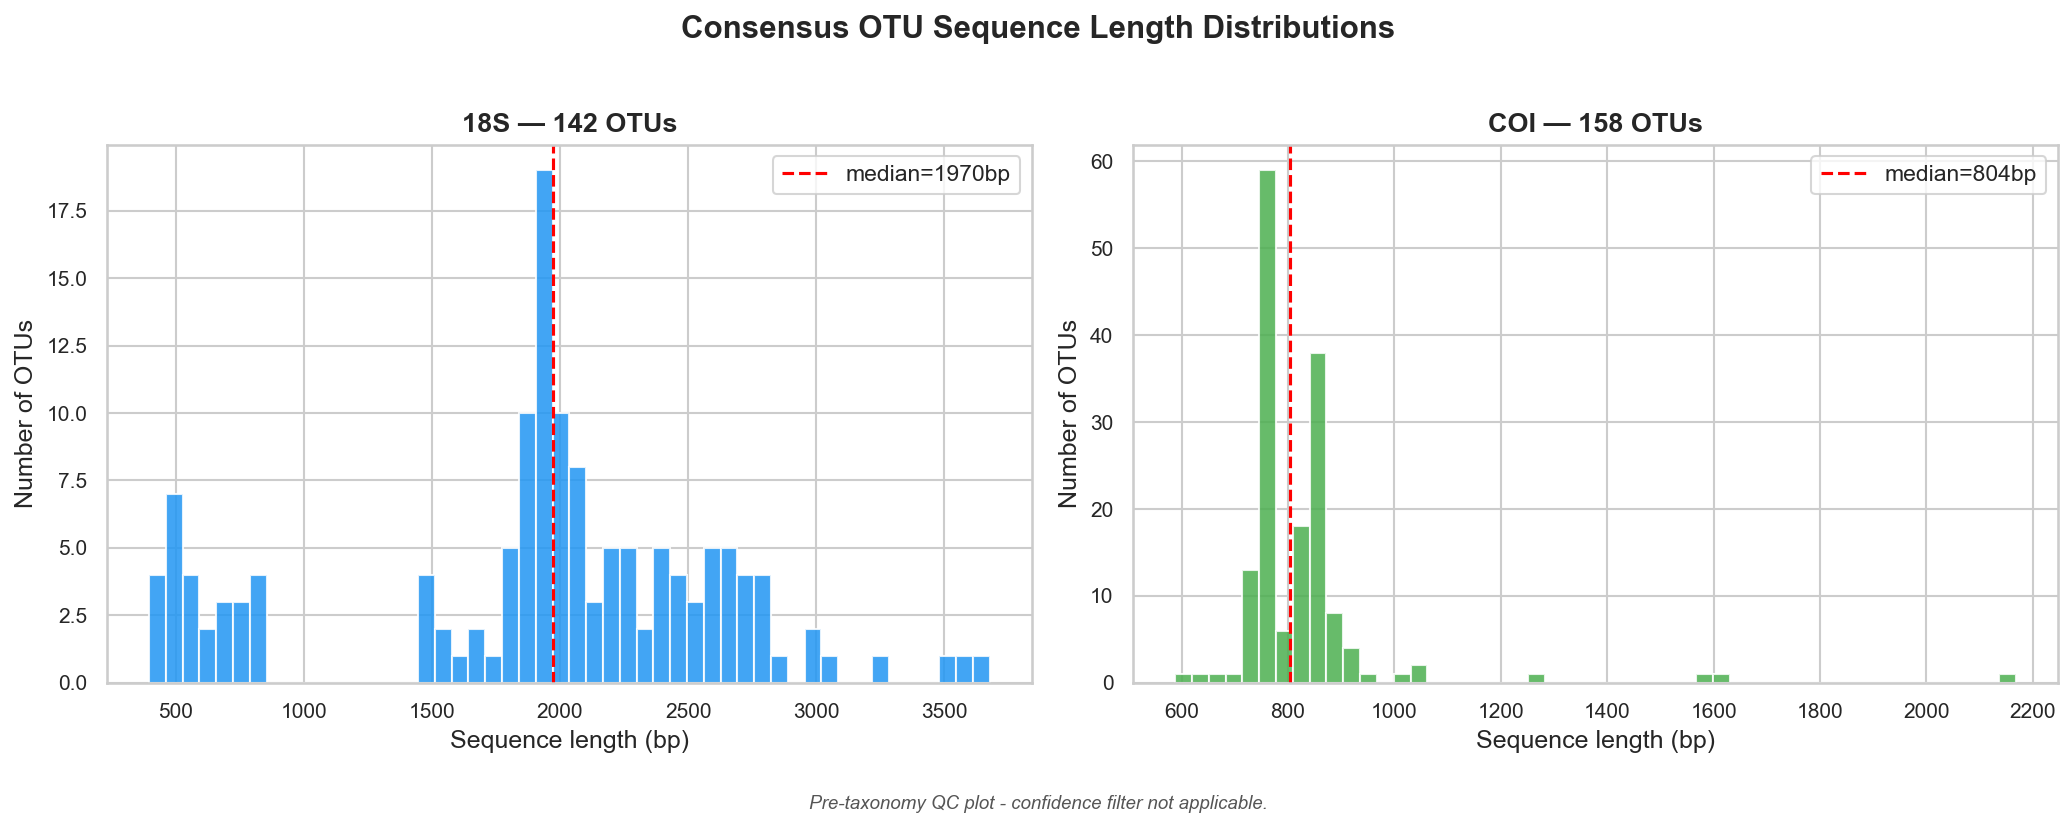

In [6]:
plot_consensus_lengths(BASE, MARKERS)

## Reads per OTU — Consensus Quality Assessment
Each OTU's consensus was built from N reads (from the `seqs=N` field):
- **More reads = higher confidence** in the consensus
- Singleton OTUs (1 read) may be noise or rare taxa
- Top OTUs with 1000+ reads are robust

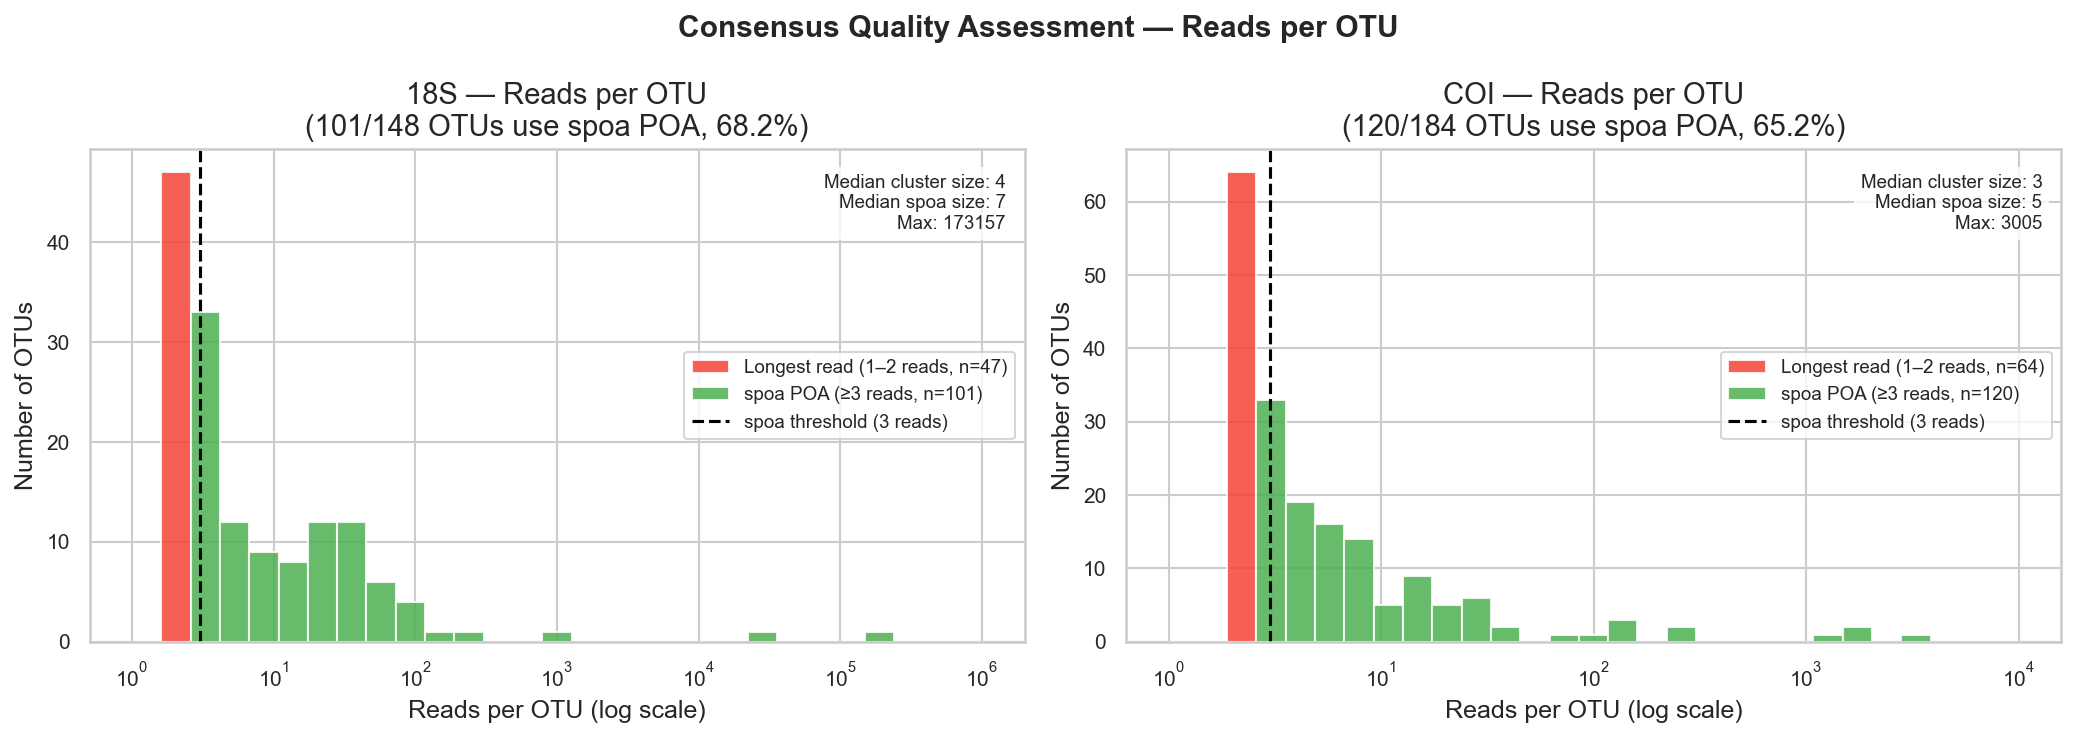

Marker     Total OTUs    spoa (≥3)  Longest rd (<3)   % spoa   Median reads  Max reads
--------------------------------------------------------------------------------
18S               148          101               47    68.2%              4     173157
COI               184          120               64    65.2%              3       3005


In [7]:
plot_reads_per_otu(BASE, MARKERS)

## Read Length Distributions: Before vs After Primer Trimming
Primer trimming removes ~20-25bp from each end (primer sequences).
This validates that primers were found and correctly removed.

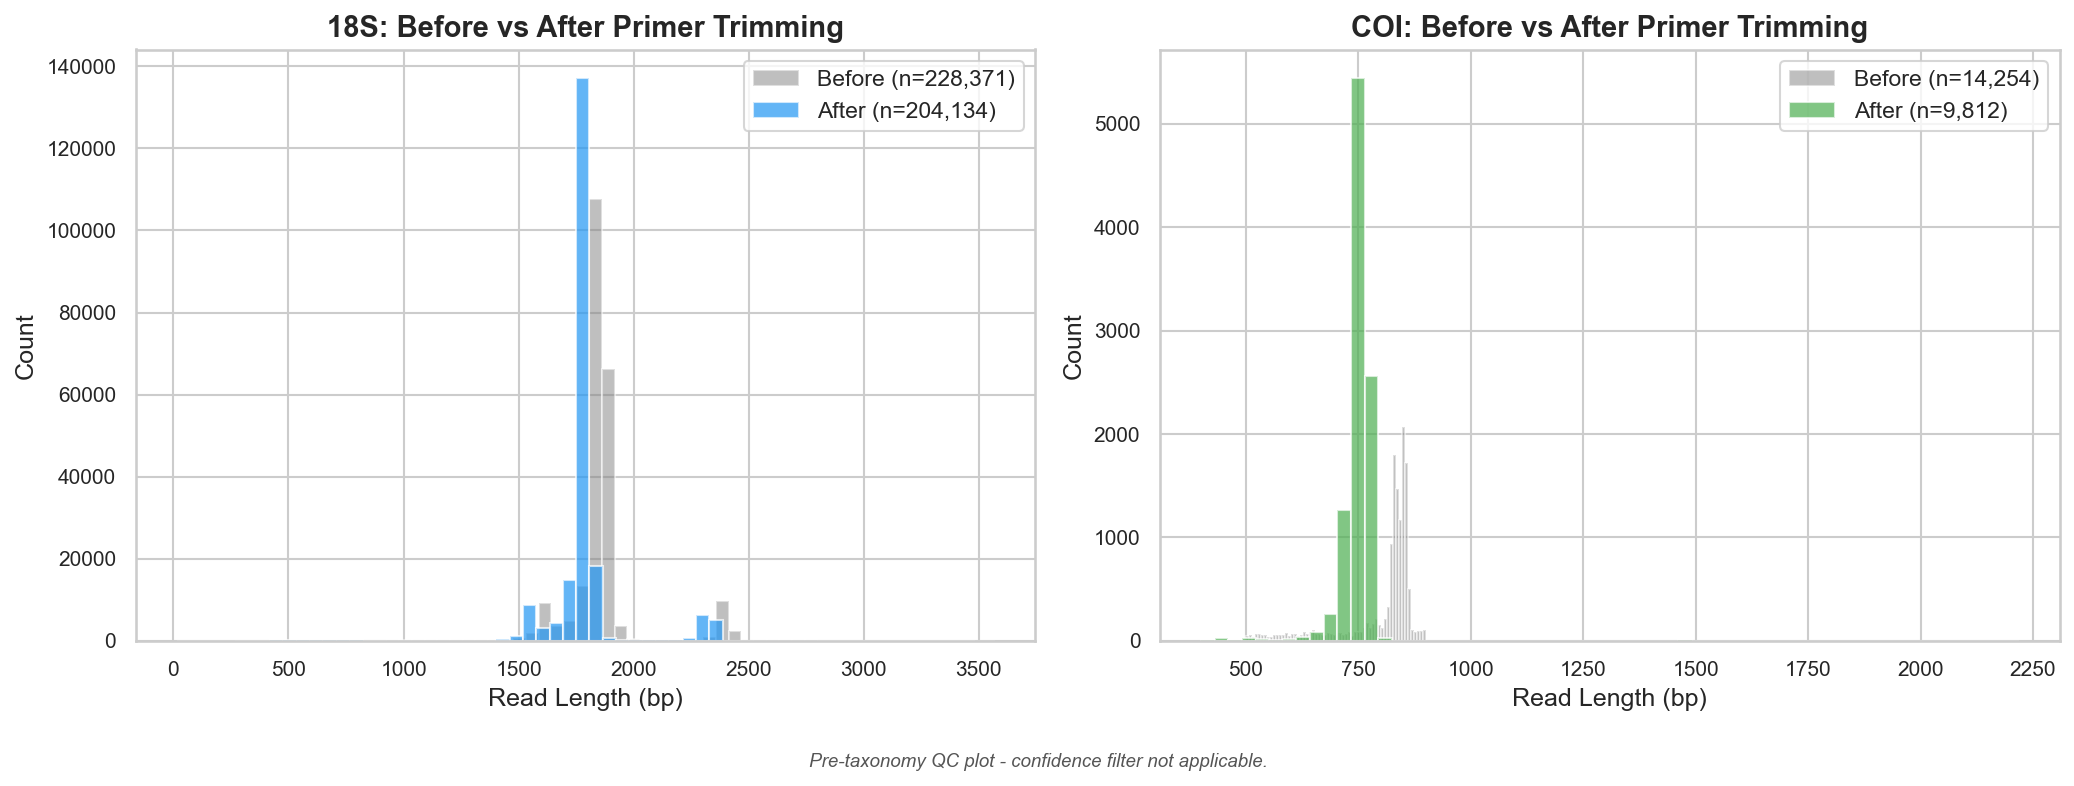

In [8]:
plot_primer_trimming(BASE, MARKERS)

## Reads per Barcode

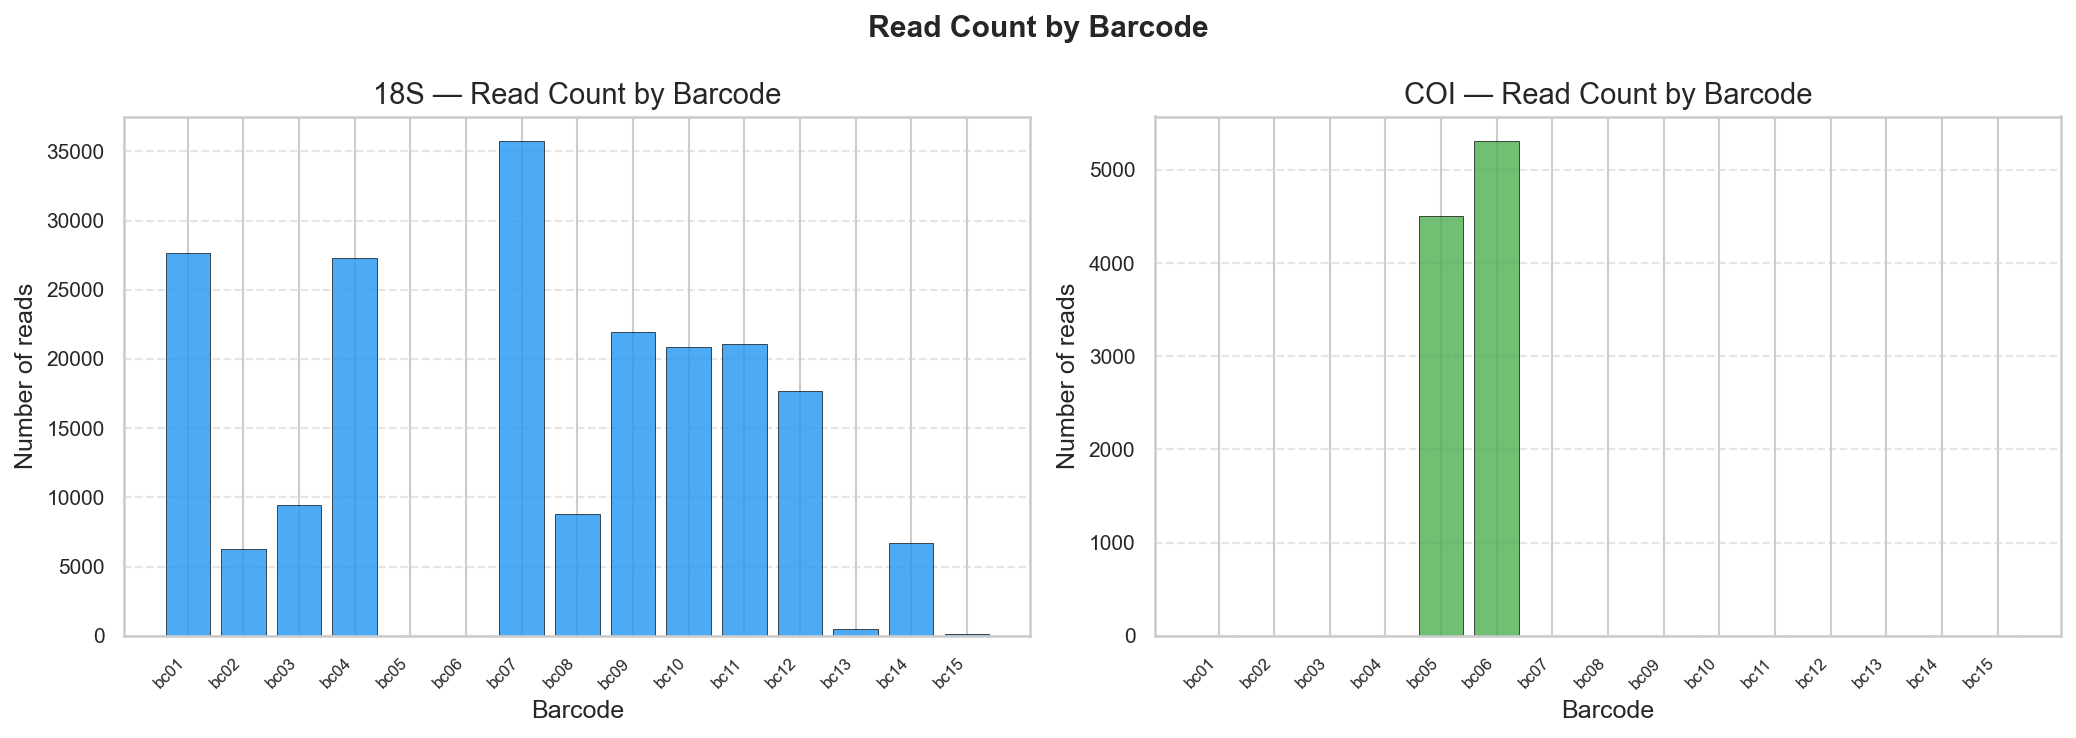

In [9]:
plot_barcode_reads(BASE, MARKERS)

# Part A: 18S Marker Biodiversity Analysis (PR2)

*Objective: Characterize planktonic community structure using 18S rRNA with PR2.*

- **Target:** Full eukaryotic diversity (protists, fungi, micro-metazoa)
- **Amplicon:** ~1400-1800 bp (SSU_1 / ITS_1dr primers)
- **OTUs:** 142 (post-chimera removal)
- **Database:** PR2

## A.1a Broad Taxonomic Structure — Phylum

[18S] Phylum: Unassigned = 0.7% of reads


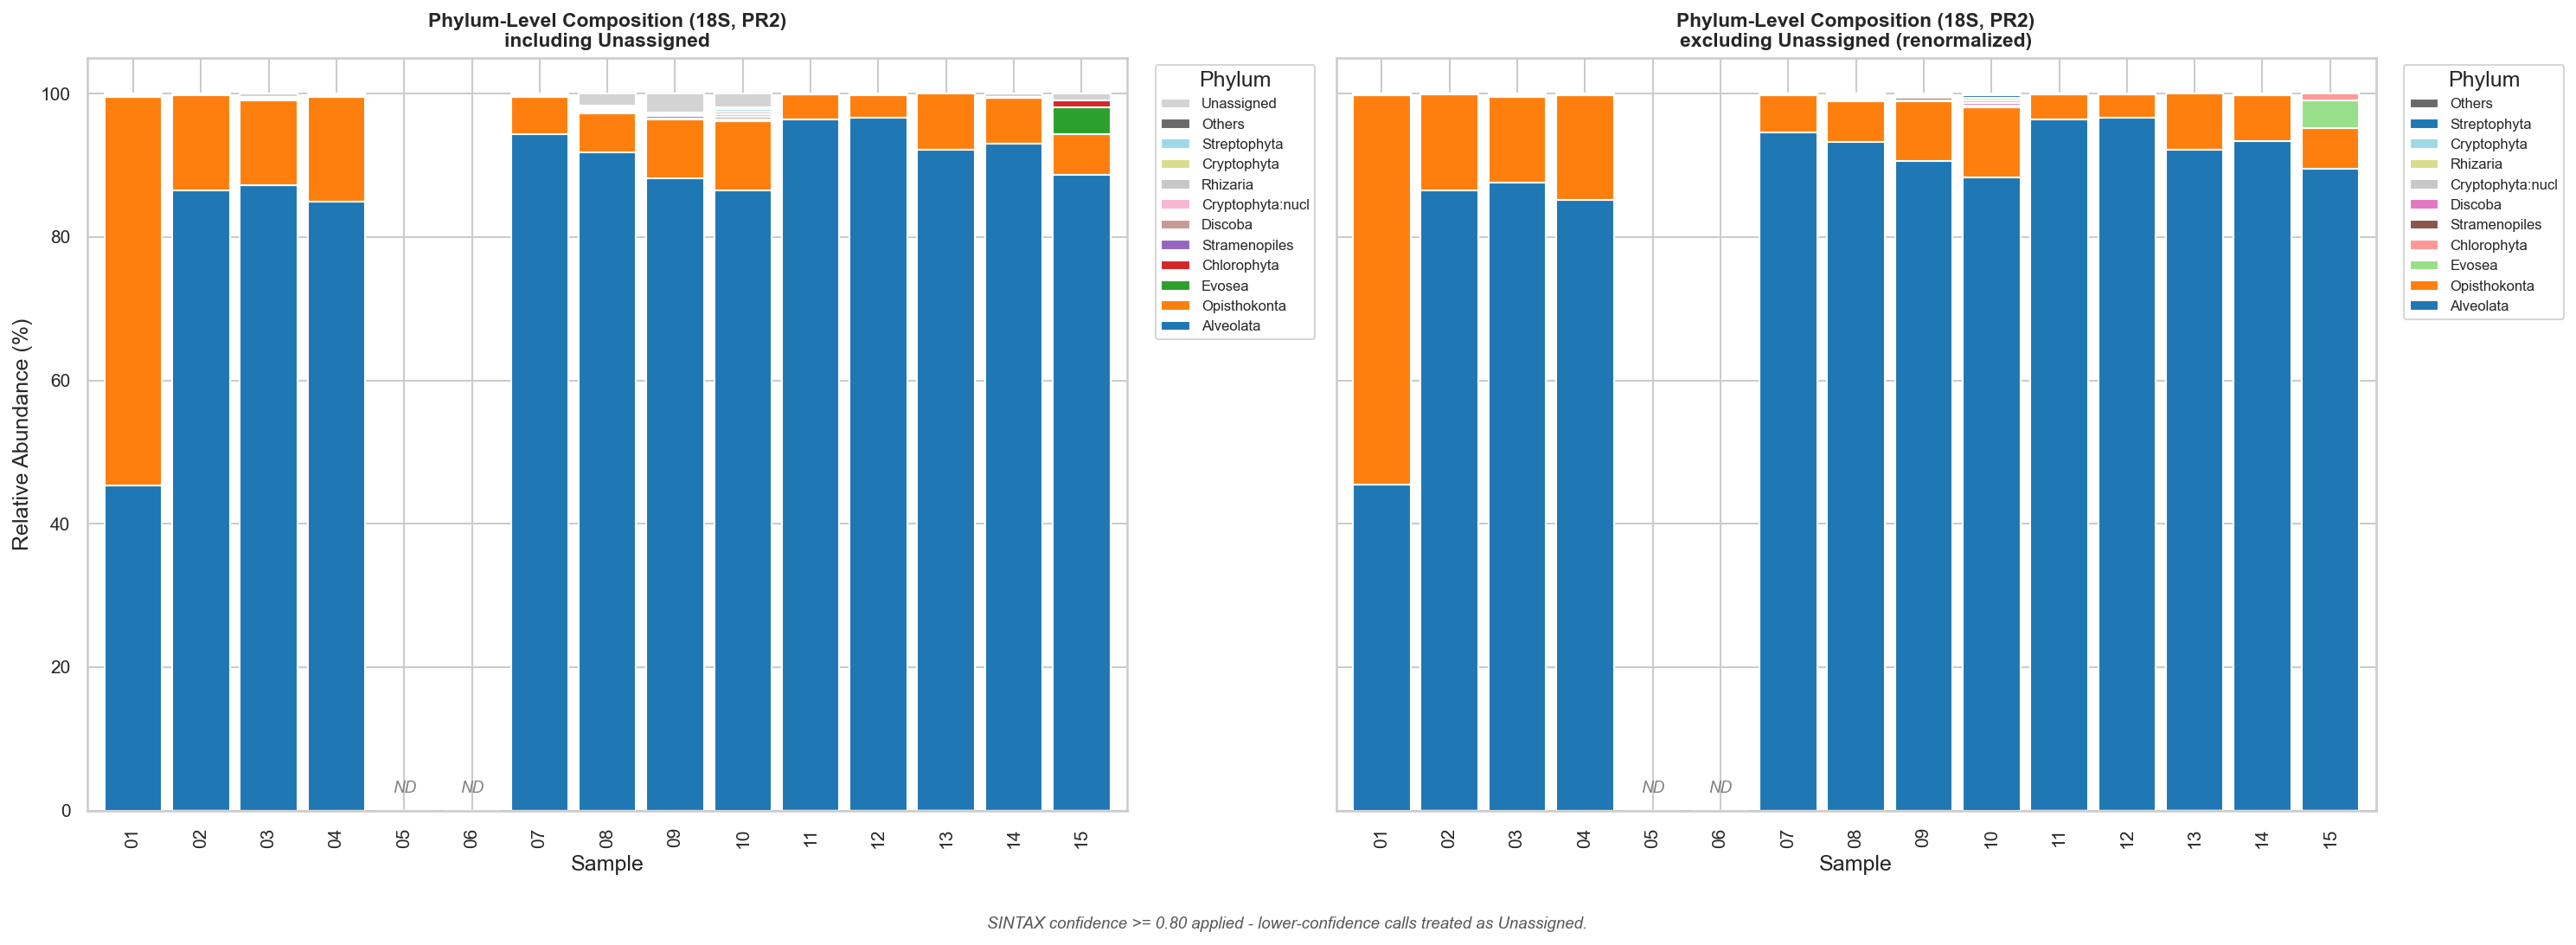

In [10]:
sample_cols_18s = get_sample_cols(df_18s)
stacked_bar_compare(df_18s, 'Phylum', prefix_18s, '18S', sample_cols_18s, top_n=10)

## A.1b Class-Level Breakdown (18S)
**Objective:** See which biological Classes dominate within the broad Phyla.
Expected: Chrysophyceae, Syndiniales, Dinophyceae, Ciliophora in lake water.

[18S] Class: Unassigned = 1.2% of reads


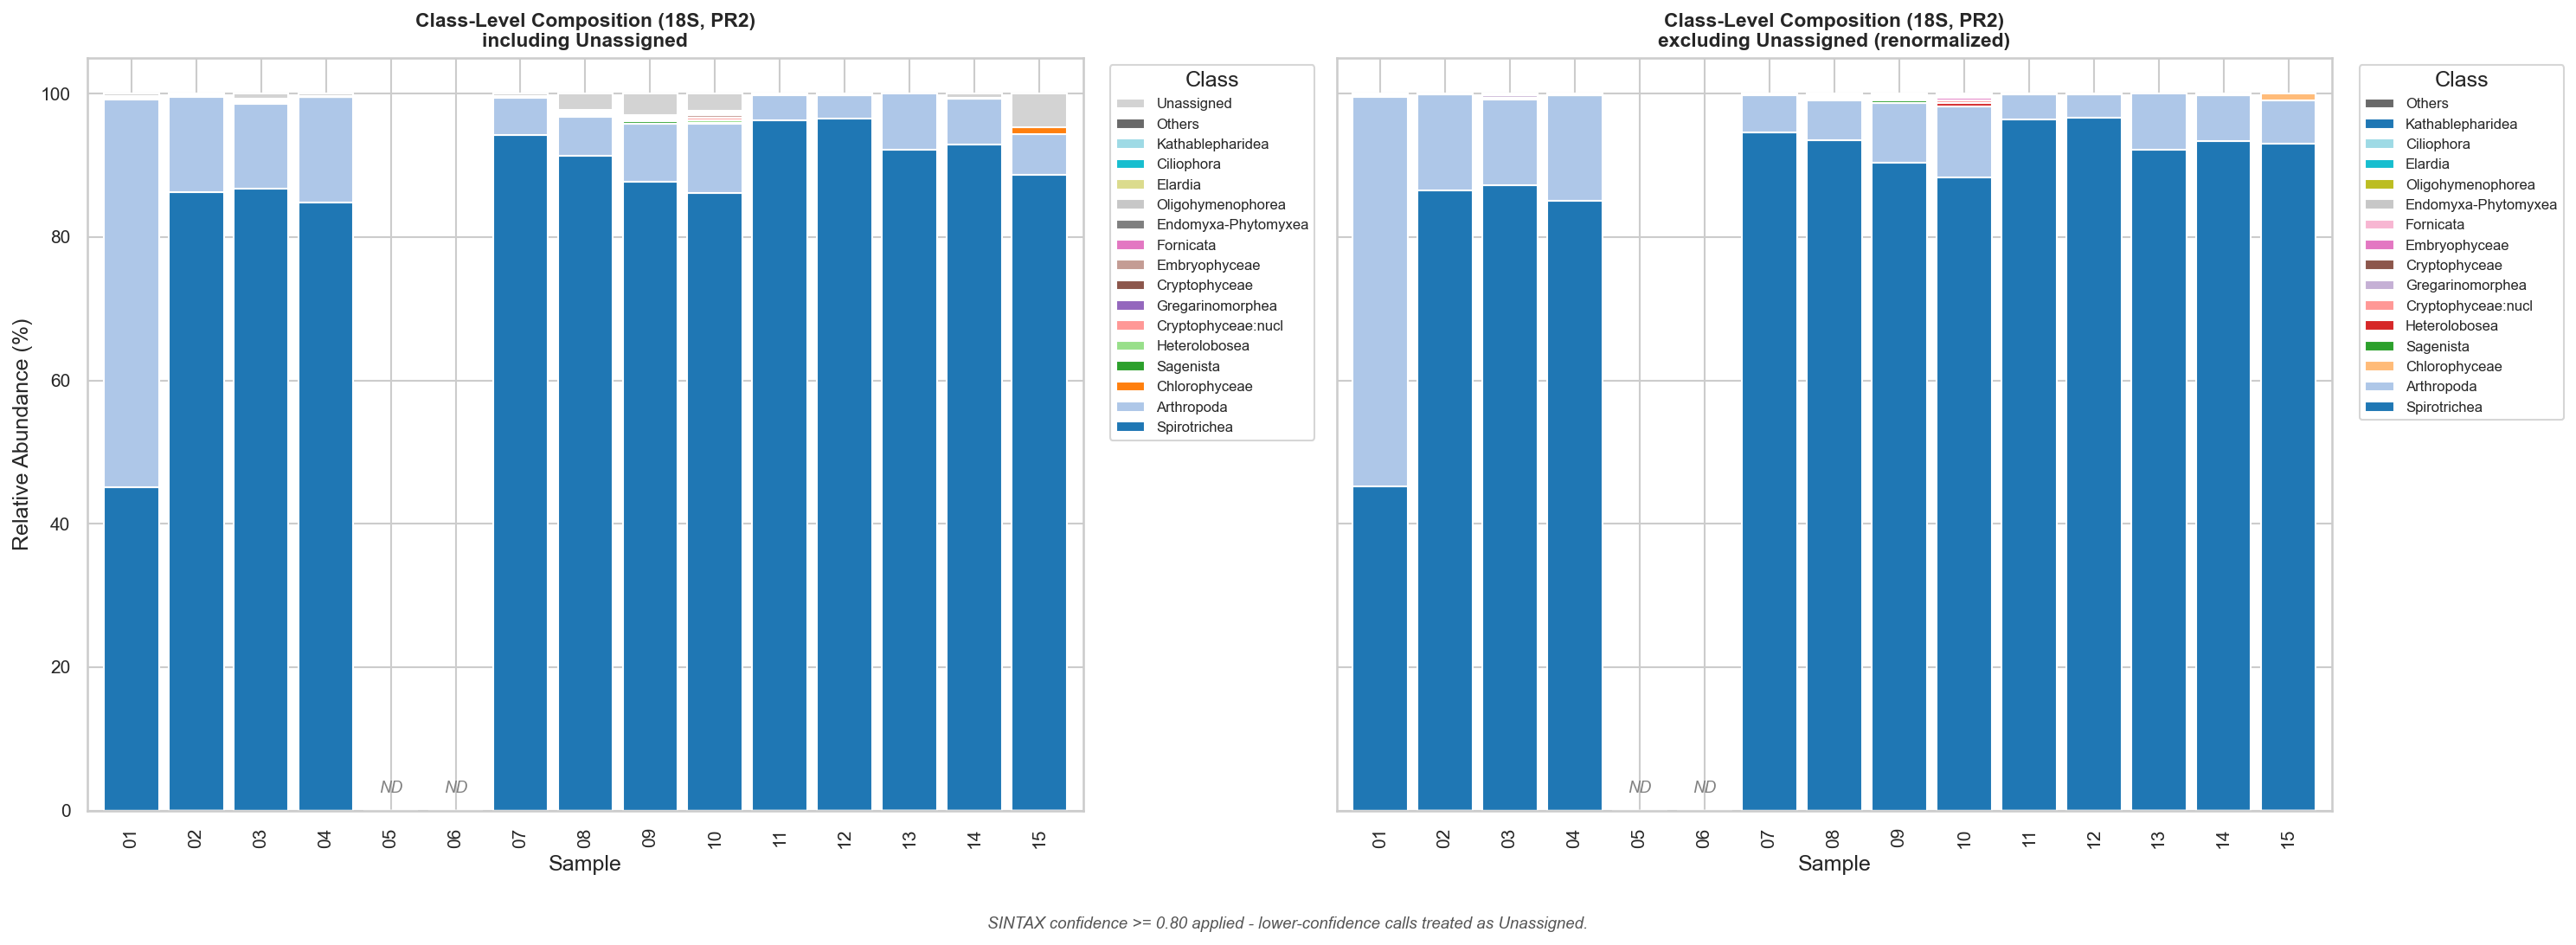

In [11]:
stacked_bar_compare(df_18s, 'Class', prefix_18s, '18S', sample_cols_18s, top_n=15)

## A.2 Order-Level Breakdown (18S)

[18S] Order: Unassigned = 1.3% of reads


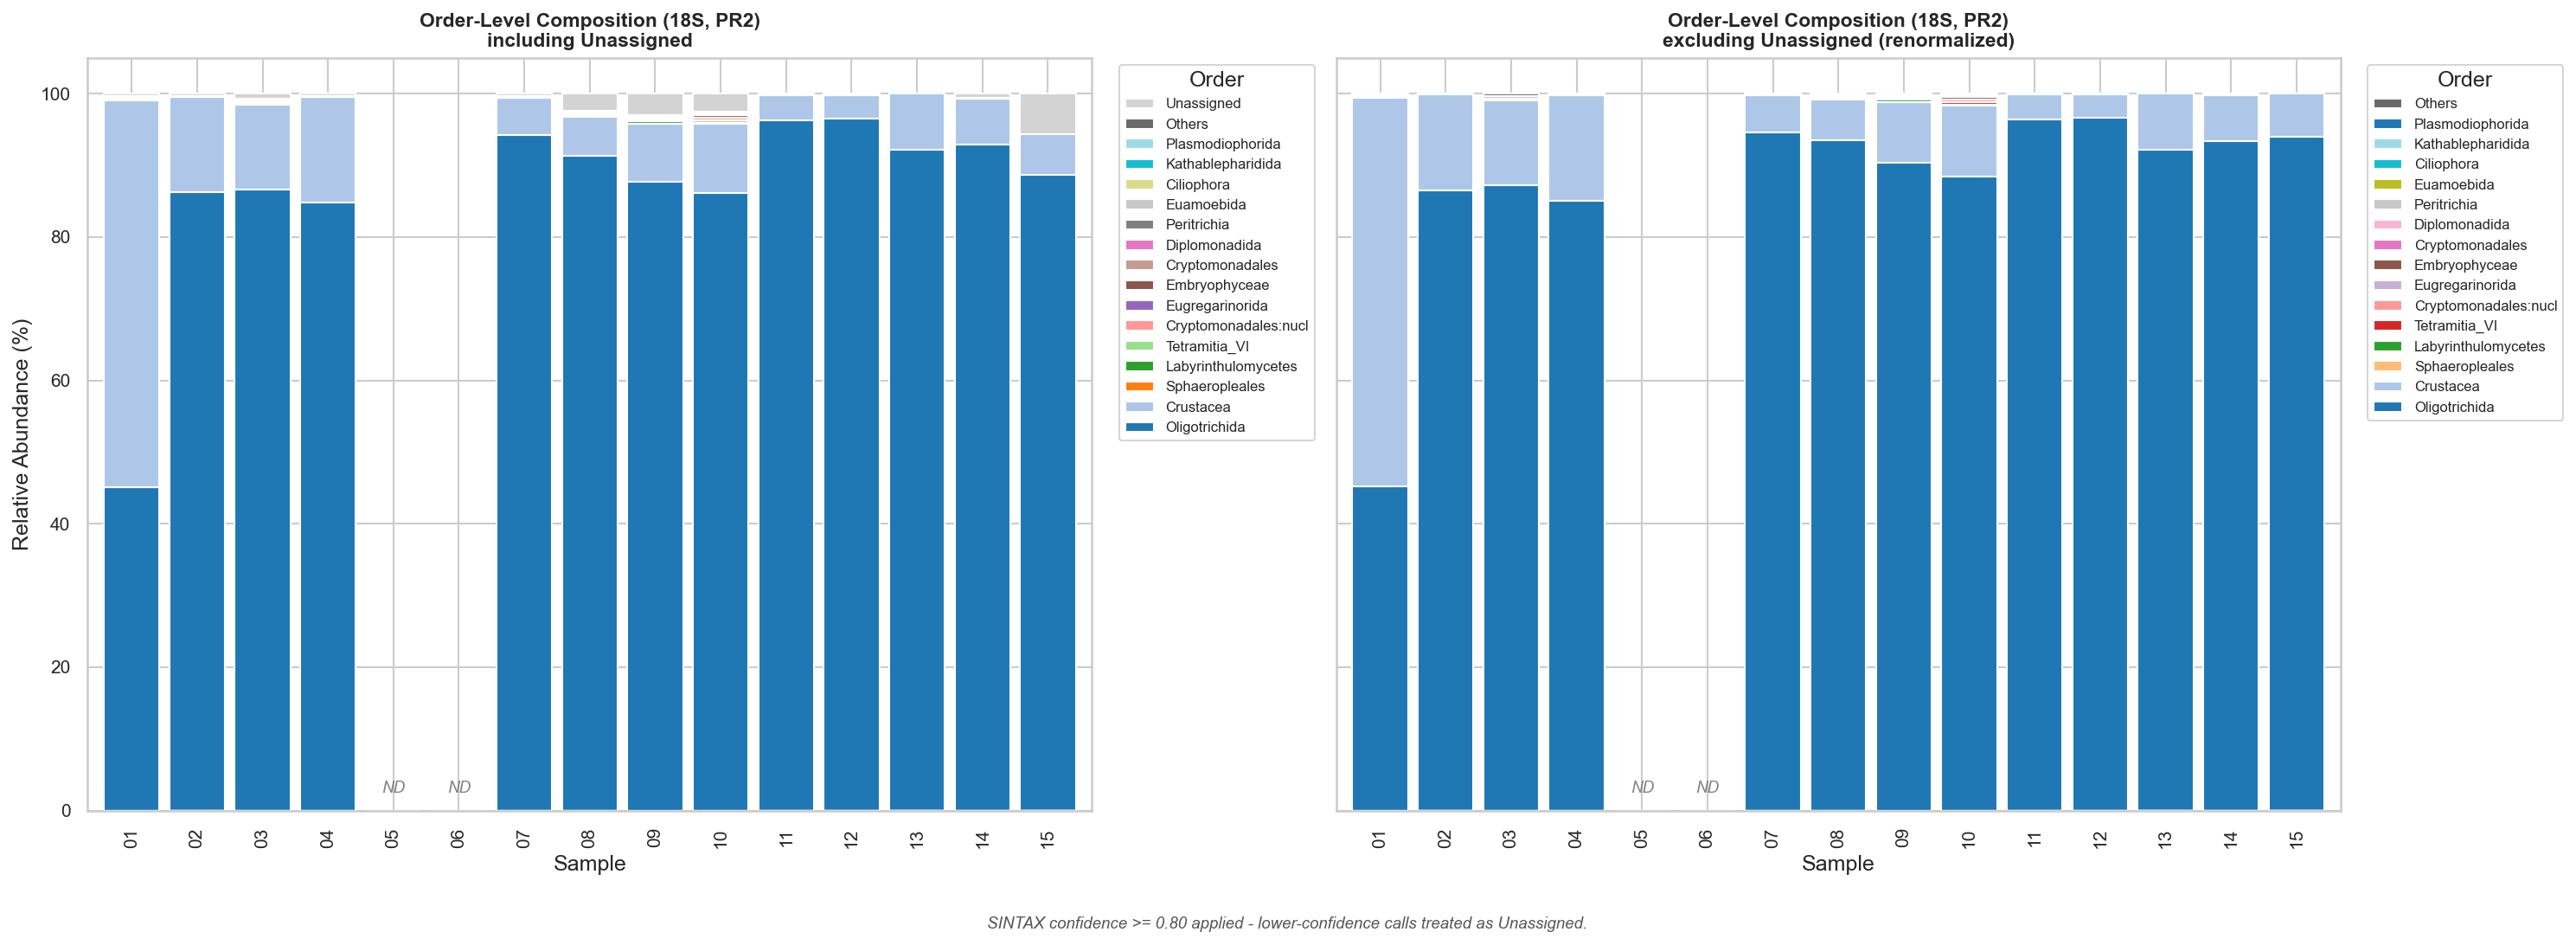

In [12]:
stacked_bar_compare(df_18s, 'Order', prefix_18s, '18S', sample_cols_18s, top_n=15)

## A.3 Genus-Level Top 20 (18S)
Top genera detected with high confidence (>= 0.8).

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:622: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top['Total'], y=top.index, palette='viridis', ax=ax)


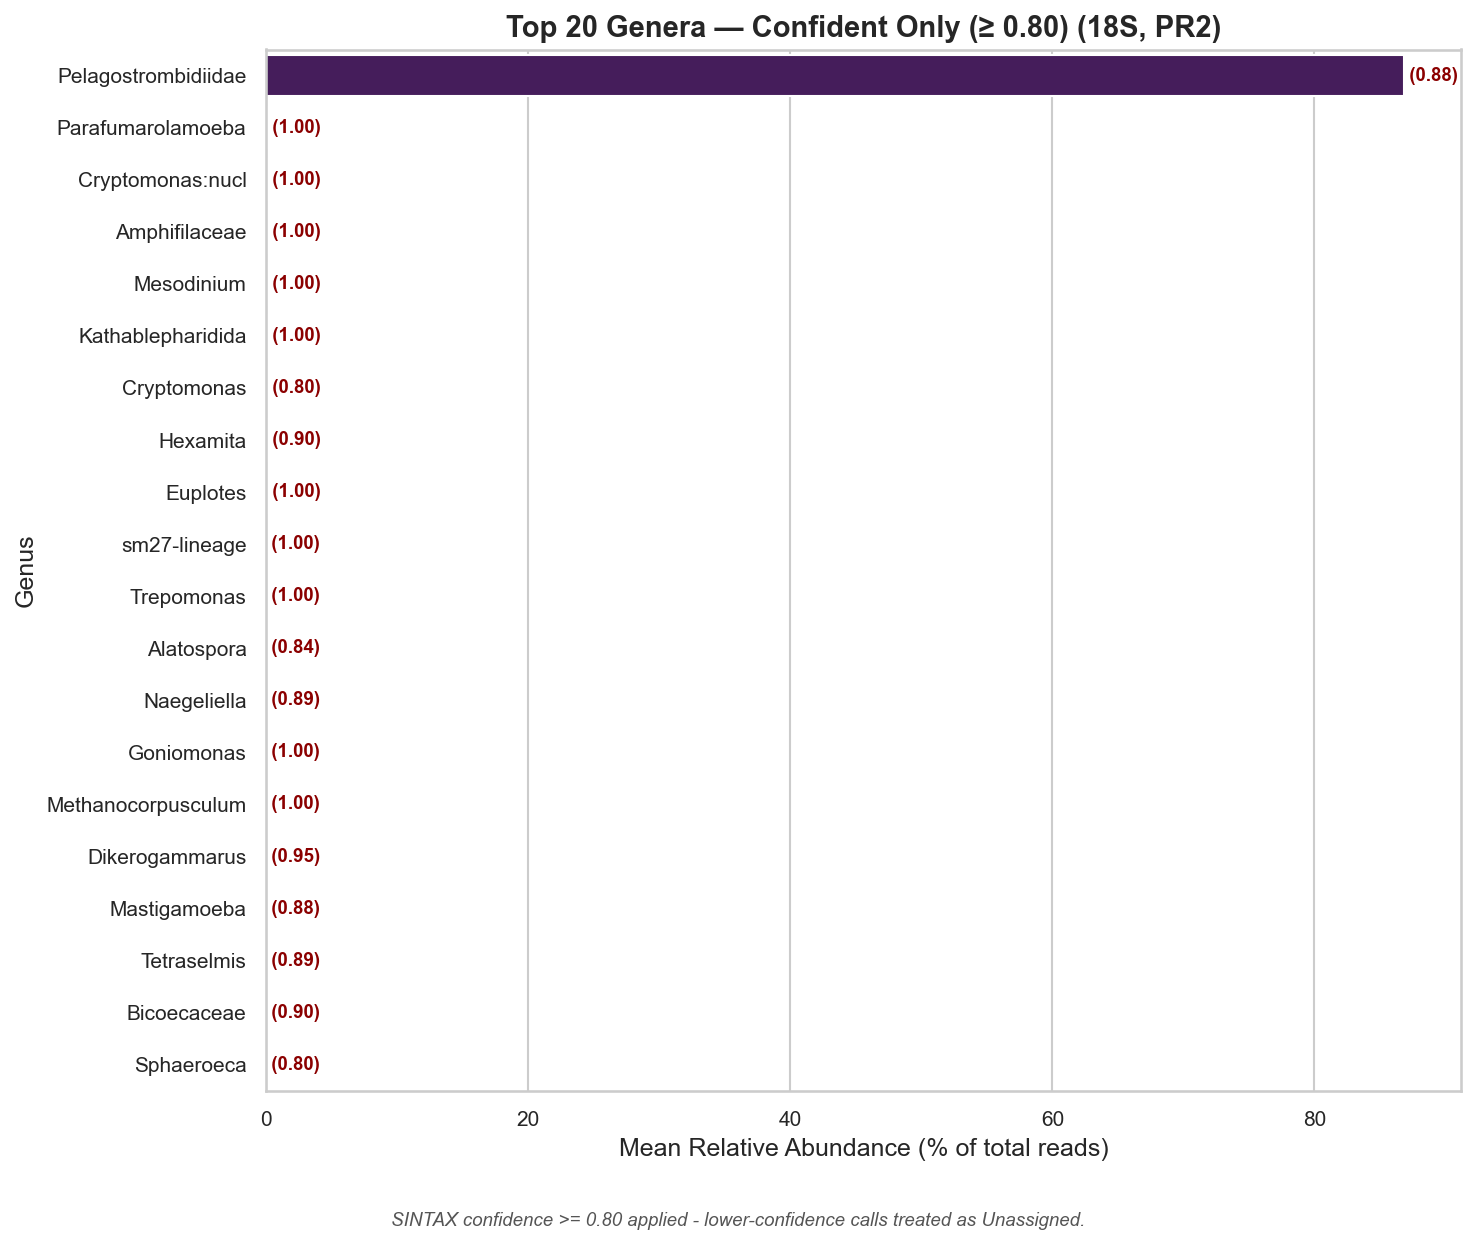

In [13]:
plot_top_genera_confident(df_18s, prefix_18s, '18S', sample_cols_18s)

### Top 20 Genera by Abundance — All Confidences (18S)
All genus assignments ranked by abundance. Bar color = mean confidence.

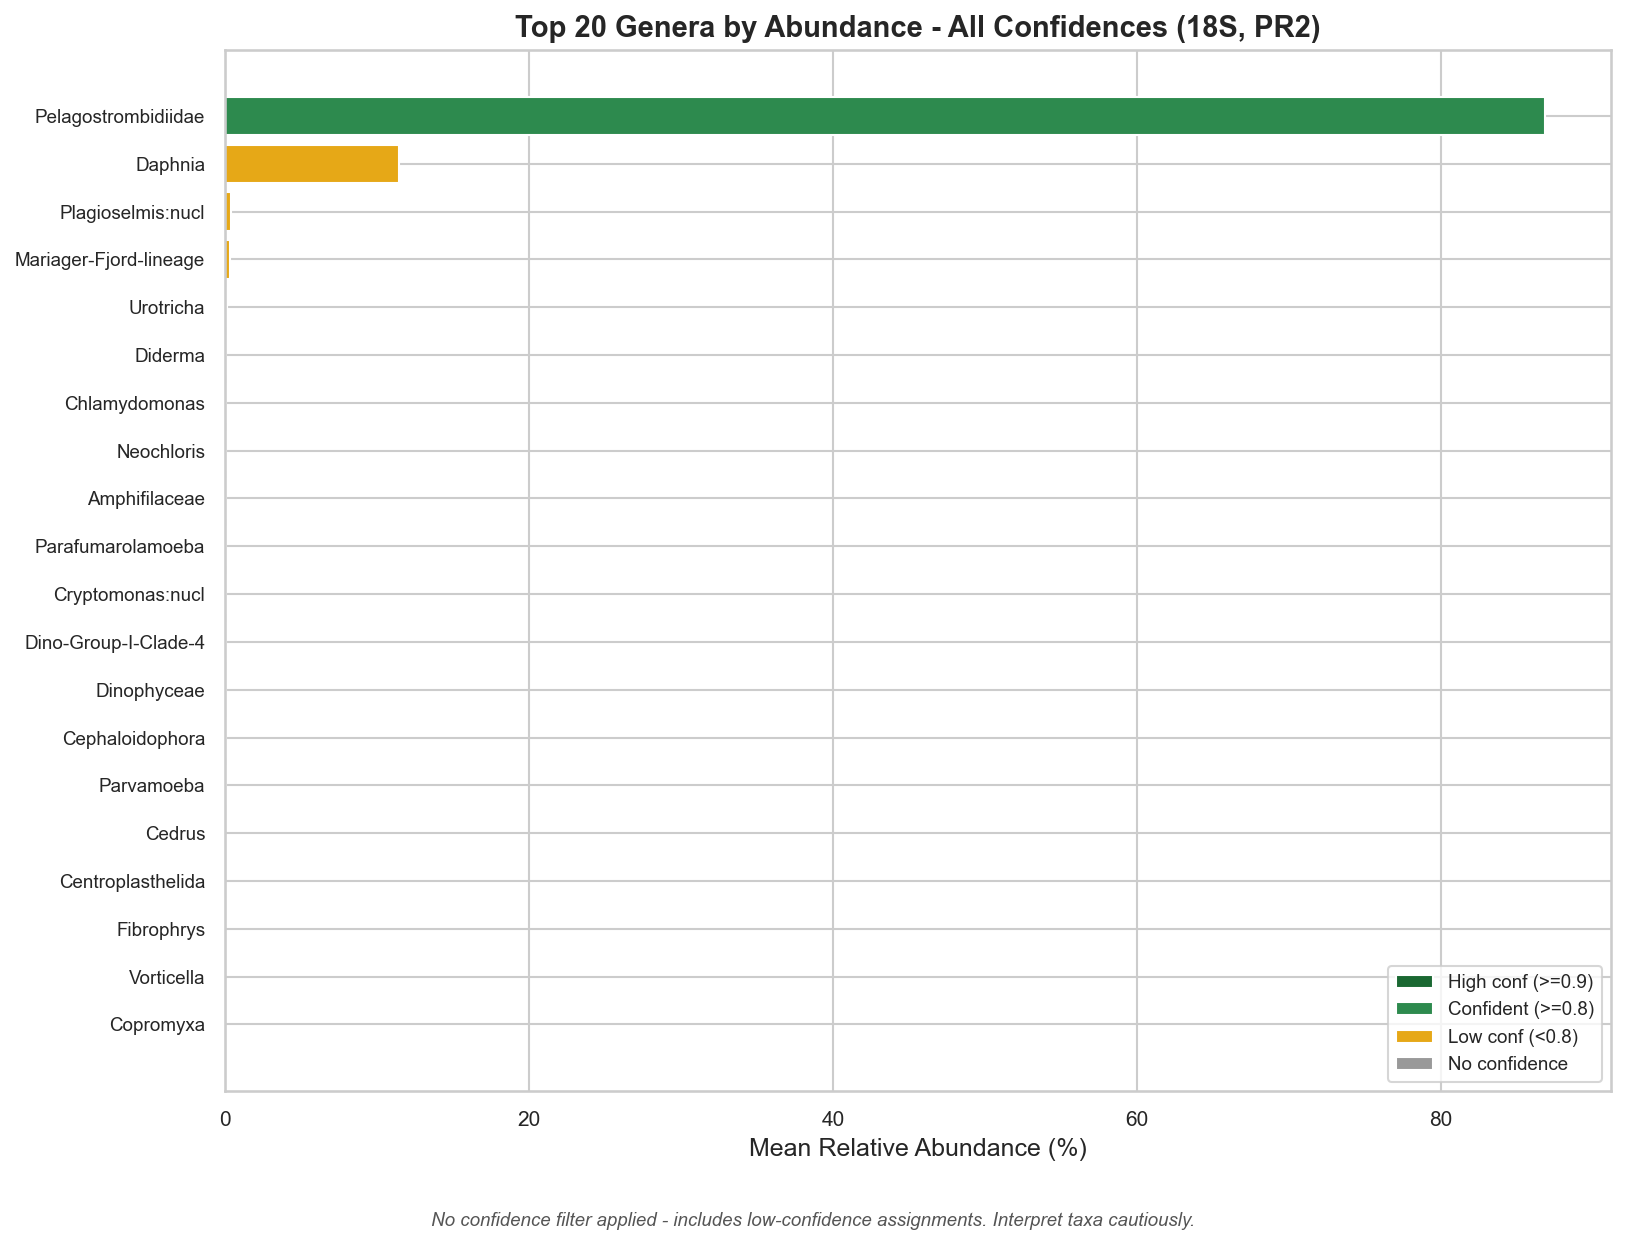

In [14]:
plot_top_genera_all(df_18s, prefix_18s, '18S', sample_cols_18s)

## A.3b Top 20 Eukaryotic Genera (18S, PR2)
Filtered to **Eukaryota domain only** with confidence >= 0.8.

Eukaryota filter: 138/142 OTUs (97.2%)


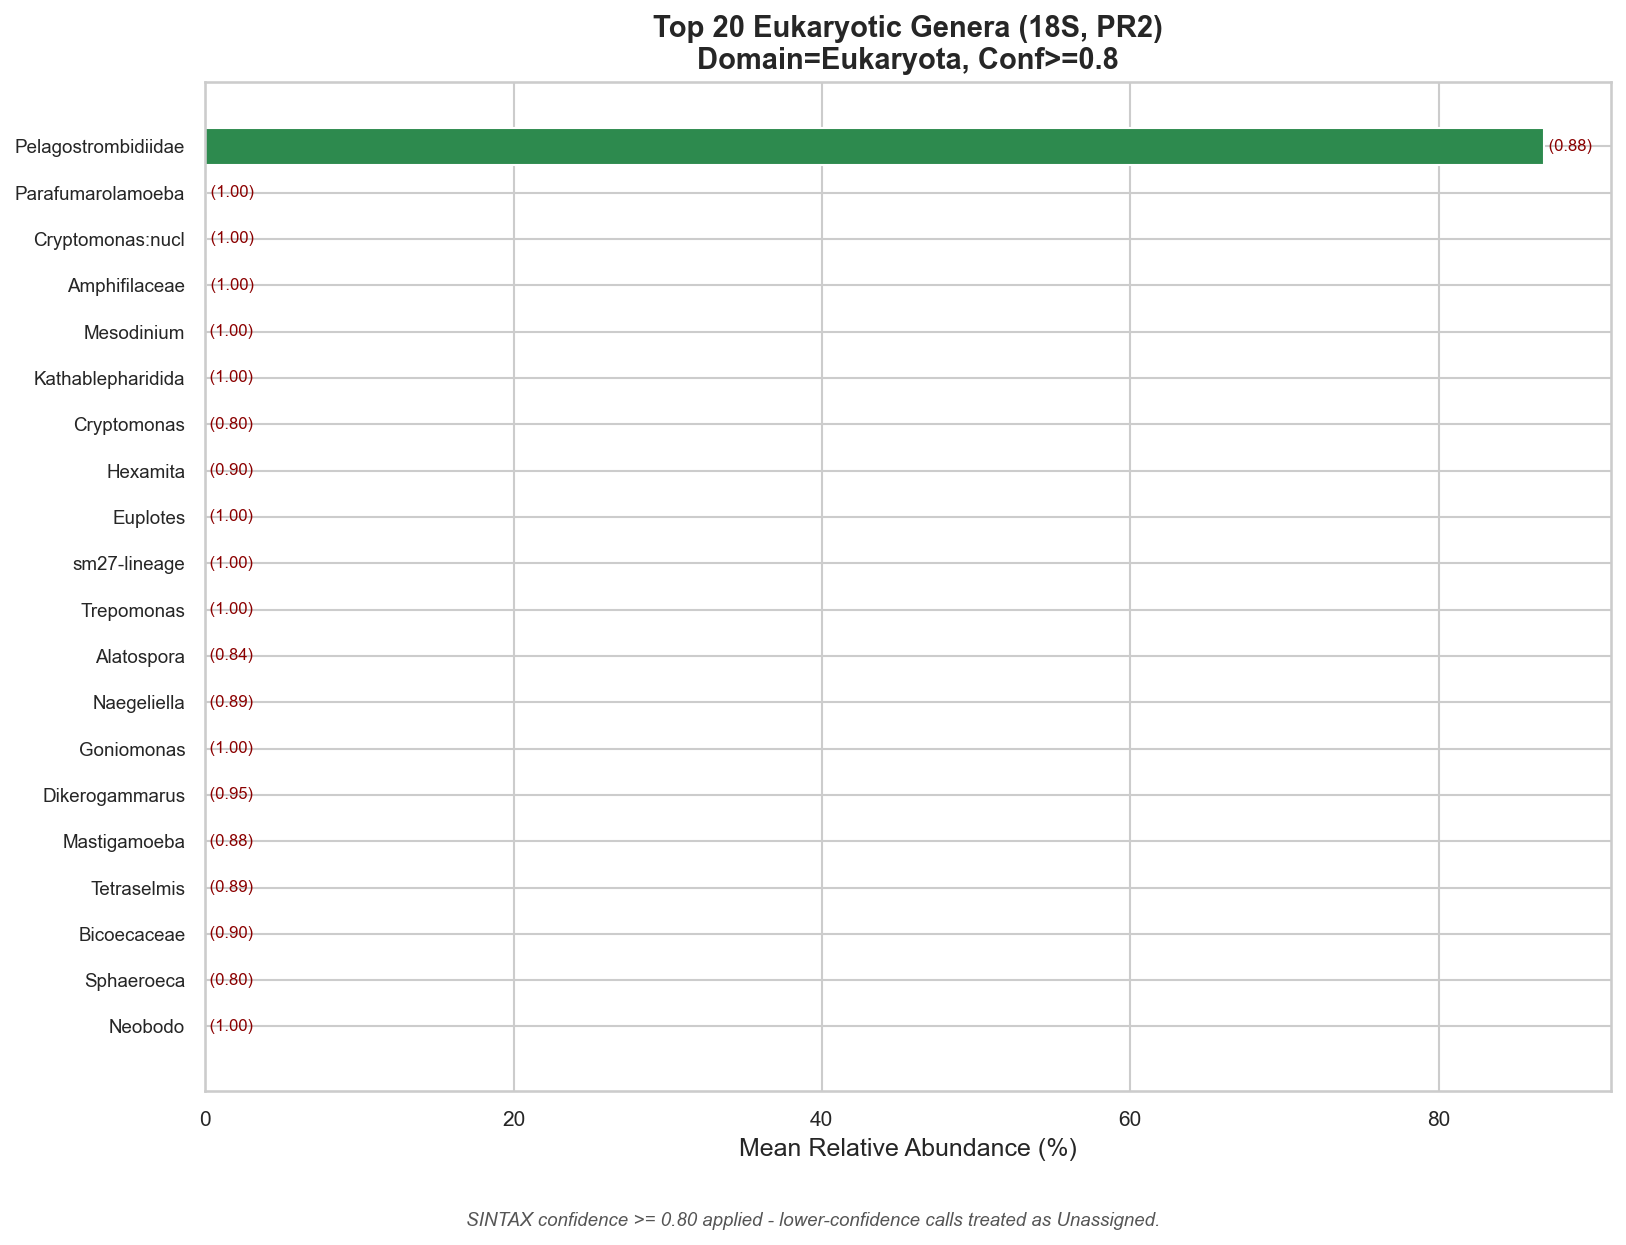

In [15]:
plot_eukaryotic_genera(df_18s, prefix_18s, '18S', sample_cols_18s)

## BLAST Validation — 18S
Top OTUs validated against NCBI GenBank via BLAST.

In [16]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_abundance_18S.txt'), '18S', 'Abundance')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_abundance_18S.txt'), df_18s, prefix_18s, '18S')

No BLAST data for 18S (Abundance)
No BLAST data for 18S table.


In [17]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_confidence_18S.txt'), '18S', 'Confidence')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_confidence_18S.txt'), df_18s, prefix_18s, '18S')

No BLAST data for 18S (Confidence)
No BLAST data for 18S table.


# Part B: COI Marker Biodiversity Analysis (MIDORI2)

*Objective: Characterize metazoan community using COI with MIDORI2.*

- **Target:** Animals (metazoa), especially invertebrates
- **Amplicon:** ~658 bp (LCO1490 / HCO2198 Folmer primers)
- **OTUs:** 195 (post-chimera removal)
- **Database:** MIDORI2
- **Note:** Only 2 barcodes (05, 06) contained COI reads — limited diversity expected.

In [18]:
# Clean COI taxonomy names
df_coi = clean_taxonomy_names(df_coi_raw.copy(), prefix_coi)
sample_cols_coi = get_sample_cols(df_coi)

## B.1a Broad Taxonomic Structure (COI)

[COI] Phylum: Unassigned = 59.0% of reads


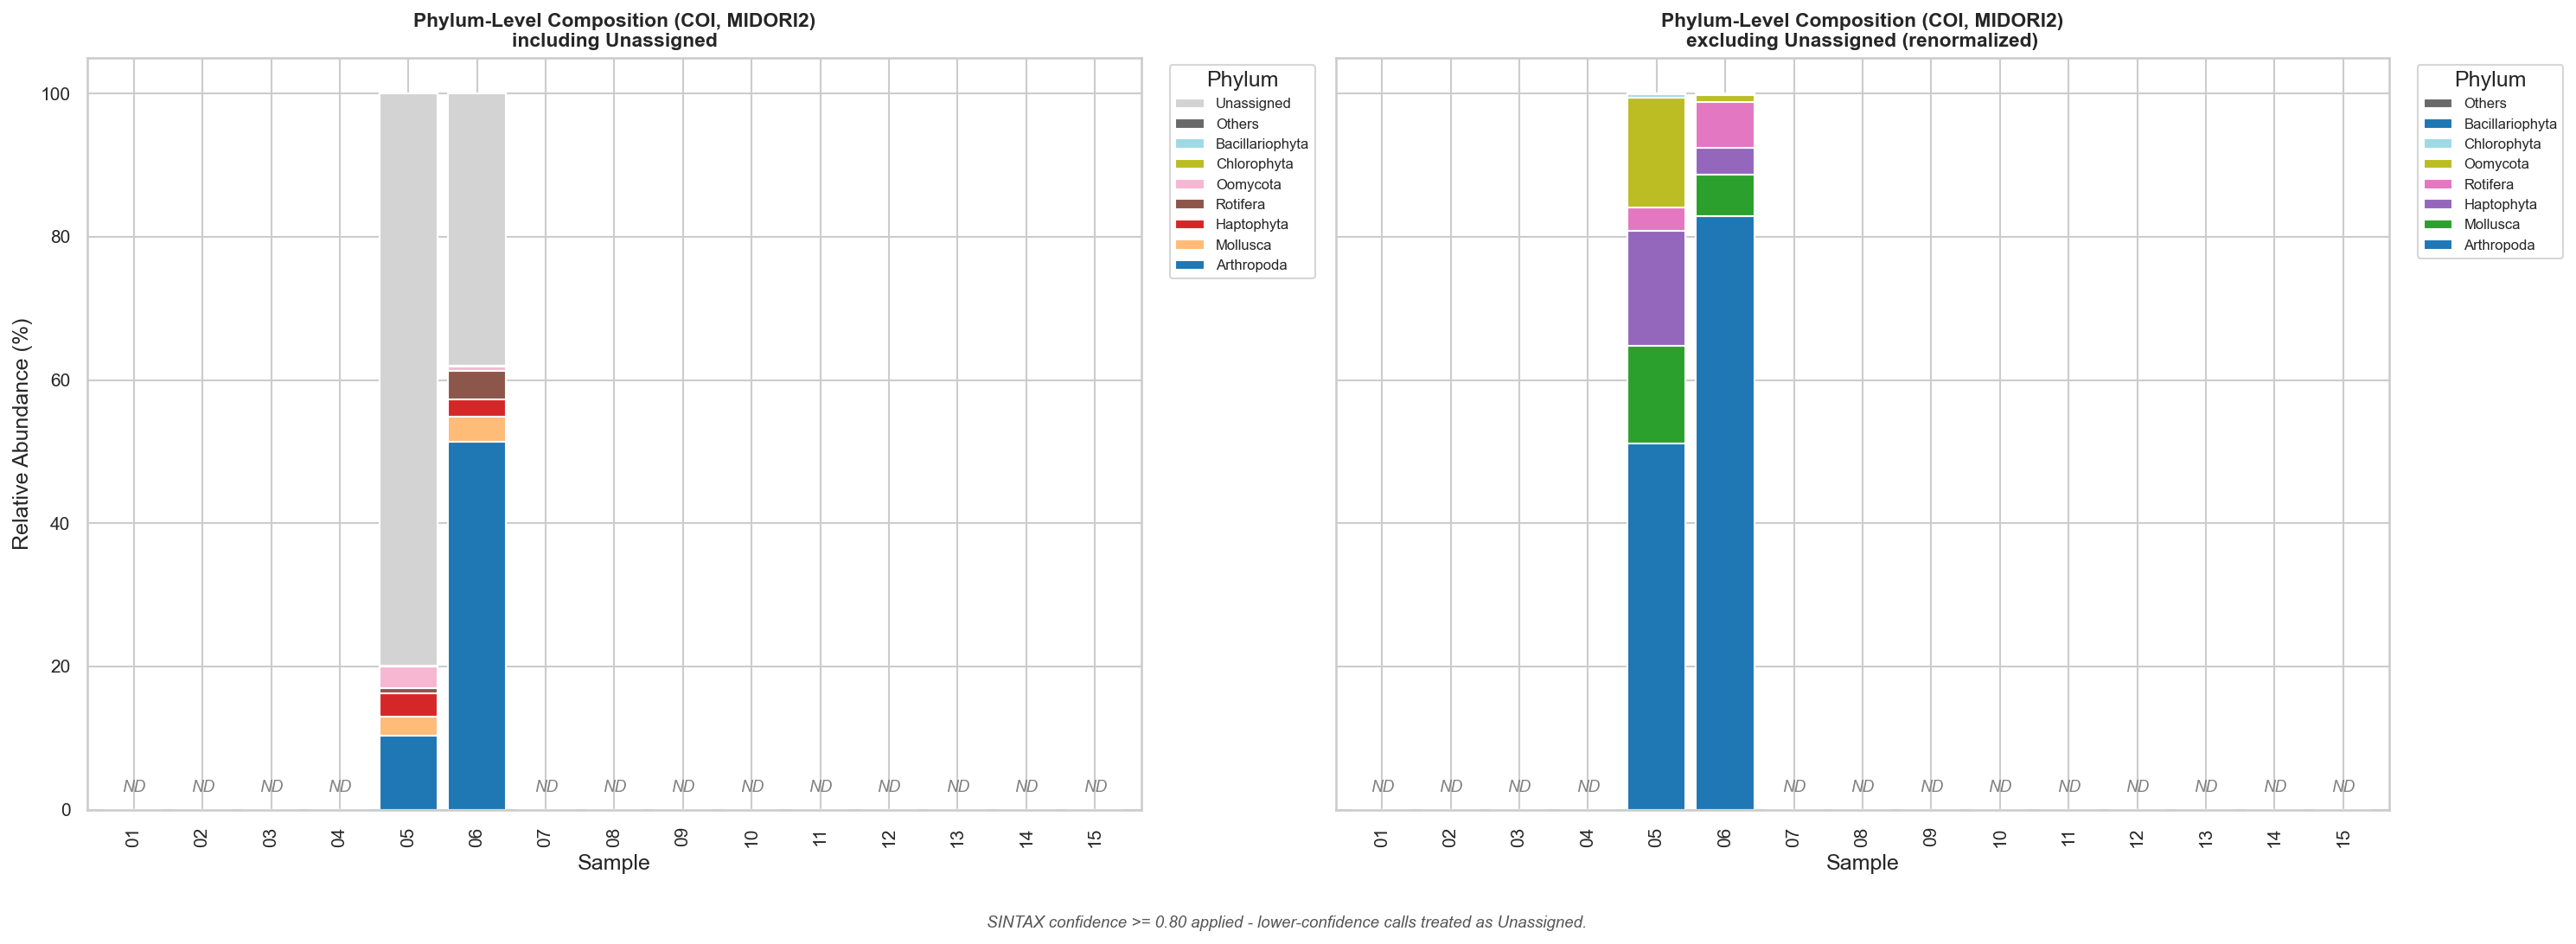

In [19]:
stacked_bar_compare(df_coi, 'Phylum', prefix_coi, 'COI', sample_cols_coi, top_n=10)

## B.1b Class-Level Breakdown (COI, MIDORI2)
Expected for lake water COI: Rotifera, Maxillopoda, Branchiopoda, Insecta.

[COI] Class: Unassigned = 59.0% of reads


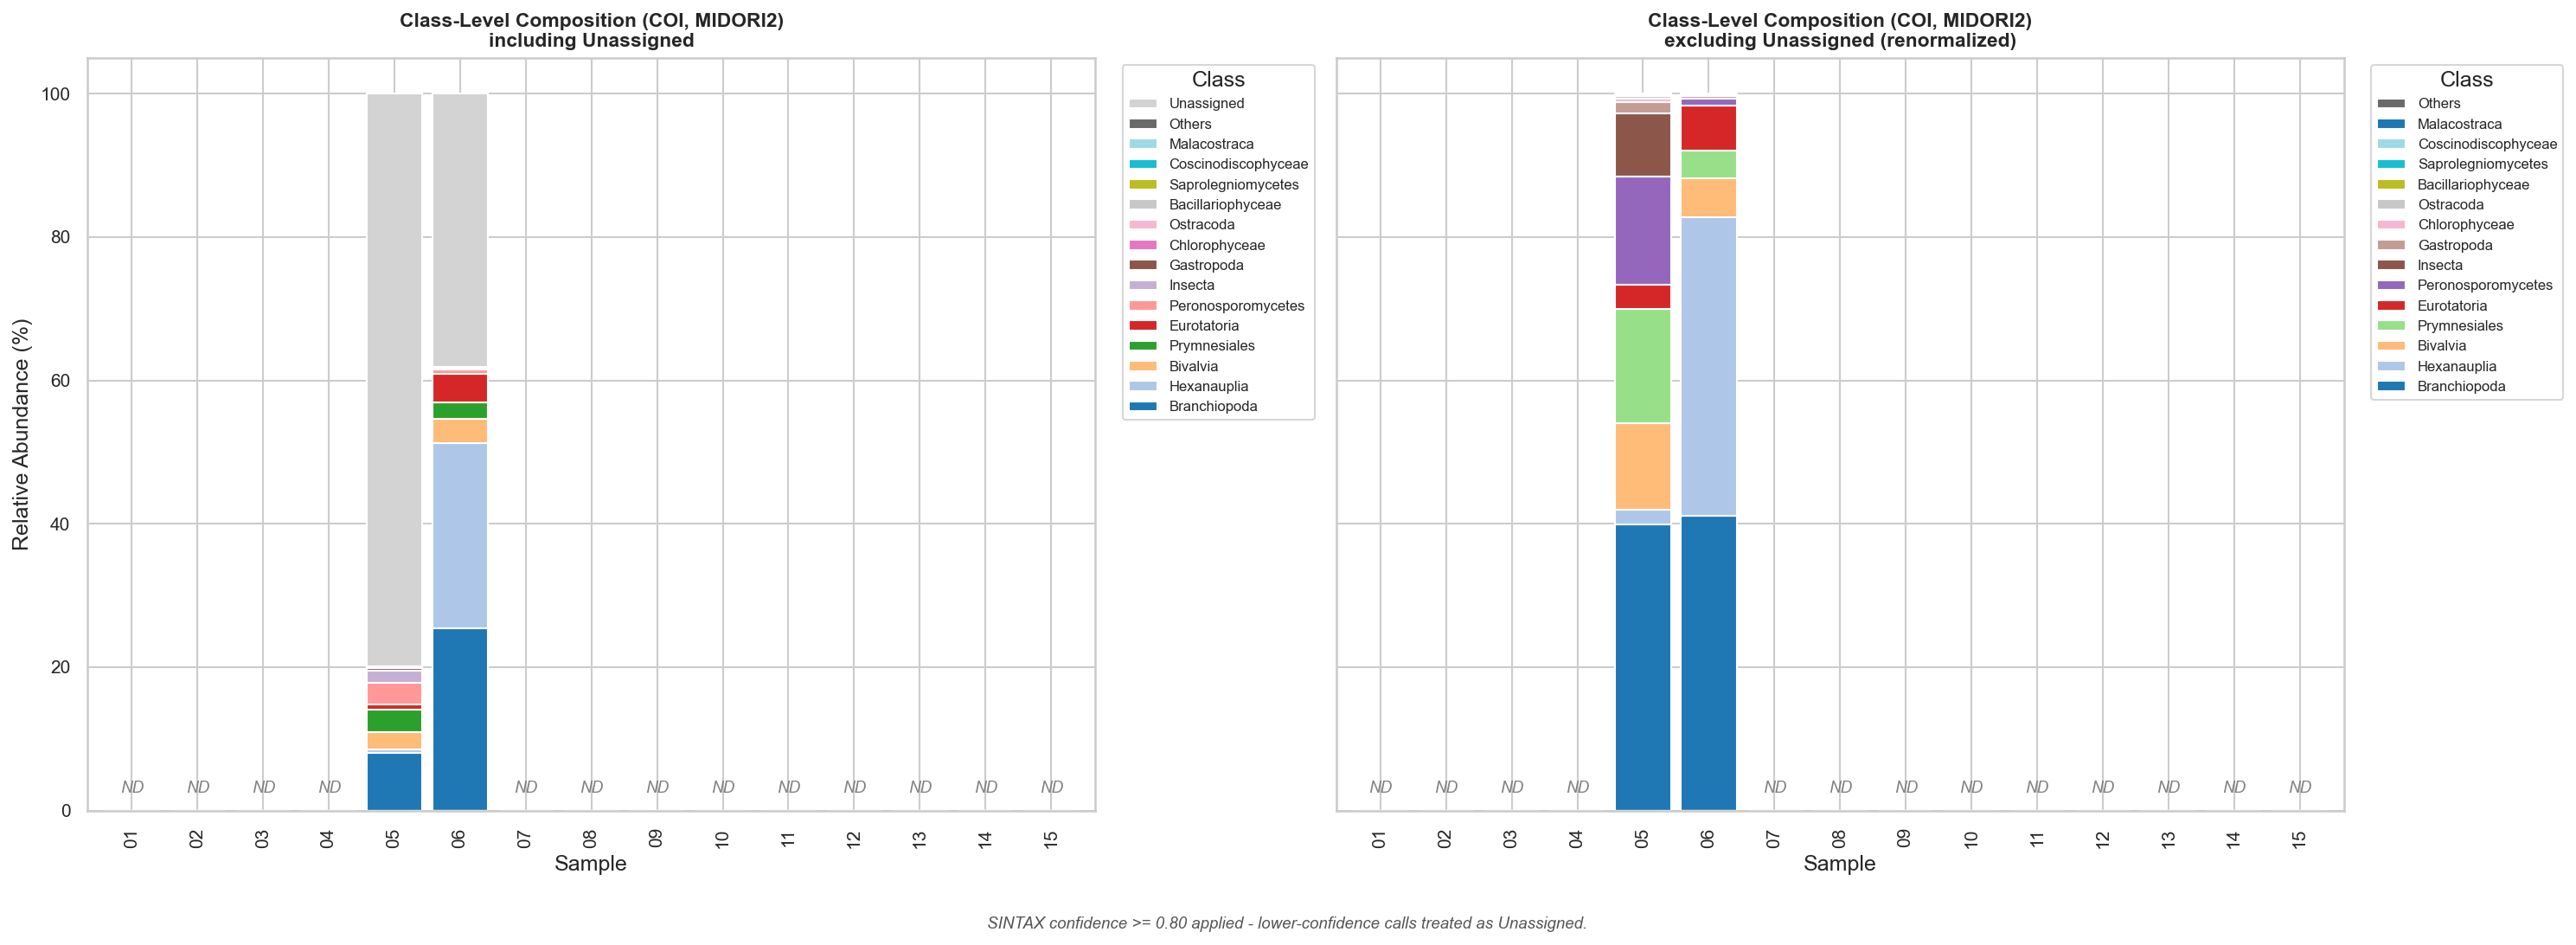

In [20]:
stacked_bar_compare(df_coi, 'Class', prefix_coi, 'COI', sample_cols_coi, top_n=15)

## B.2 Order-Level Breakdown (COI)

[COI] Order: Unassigned = 59.1% of reads


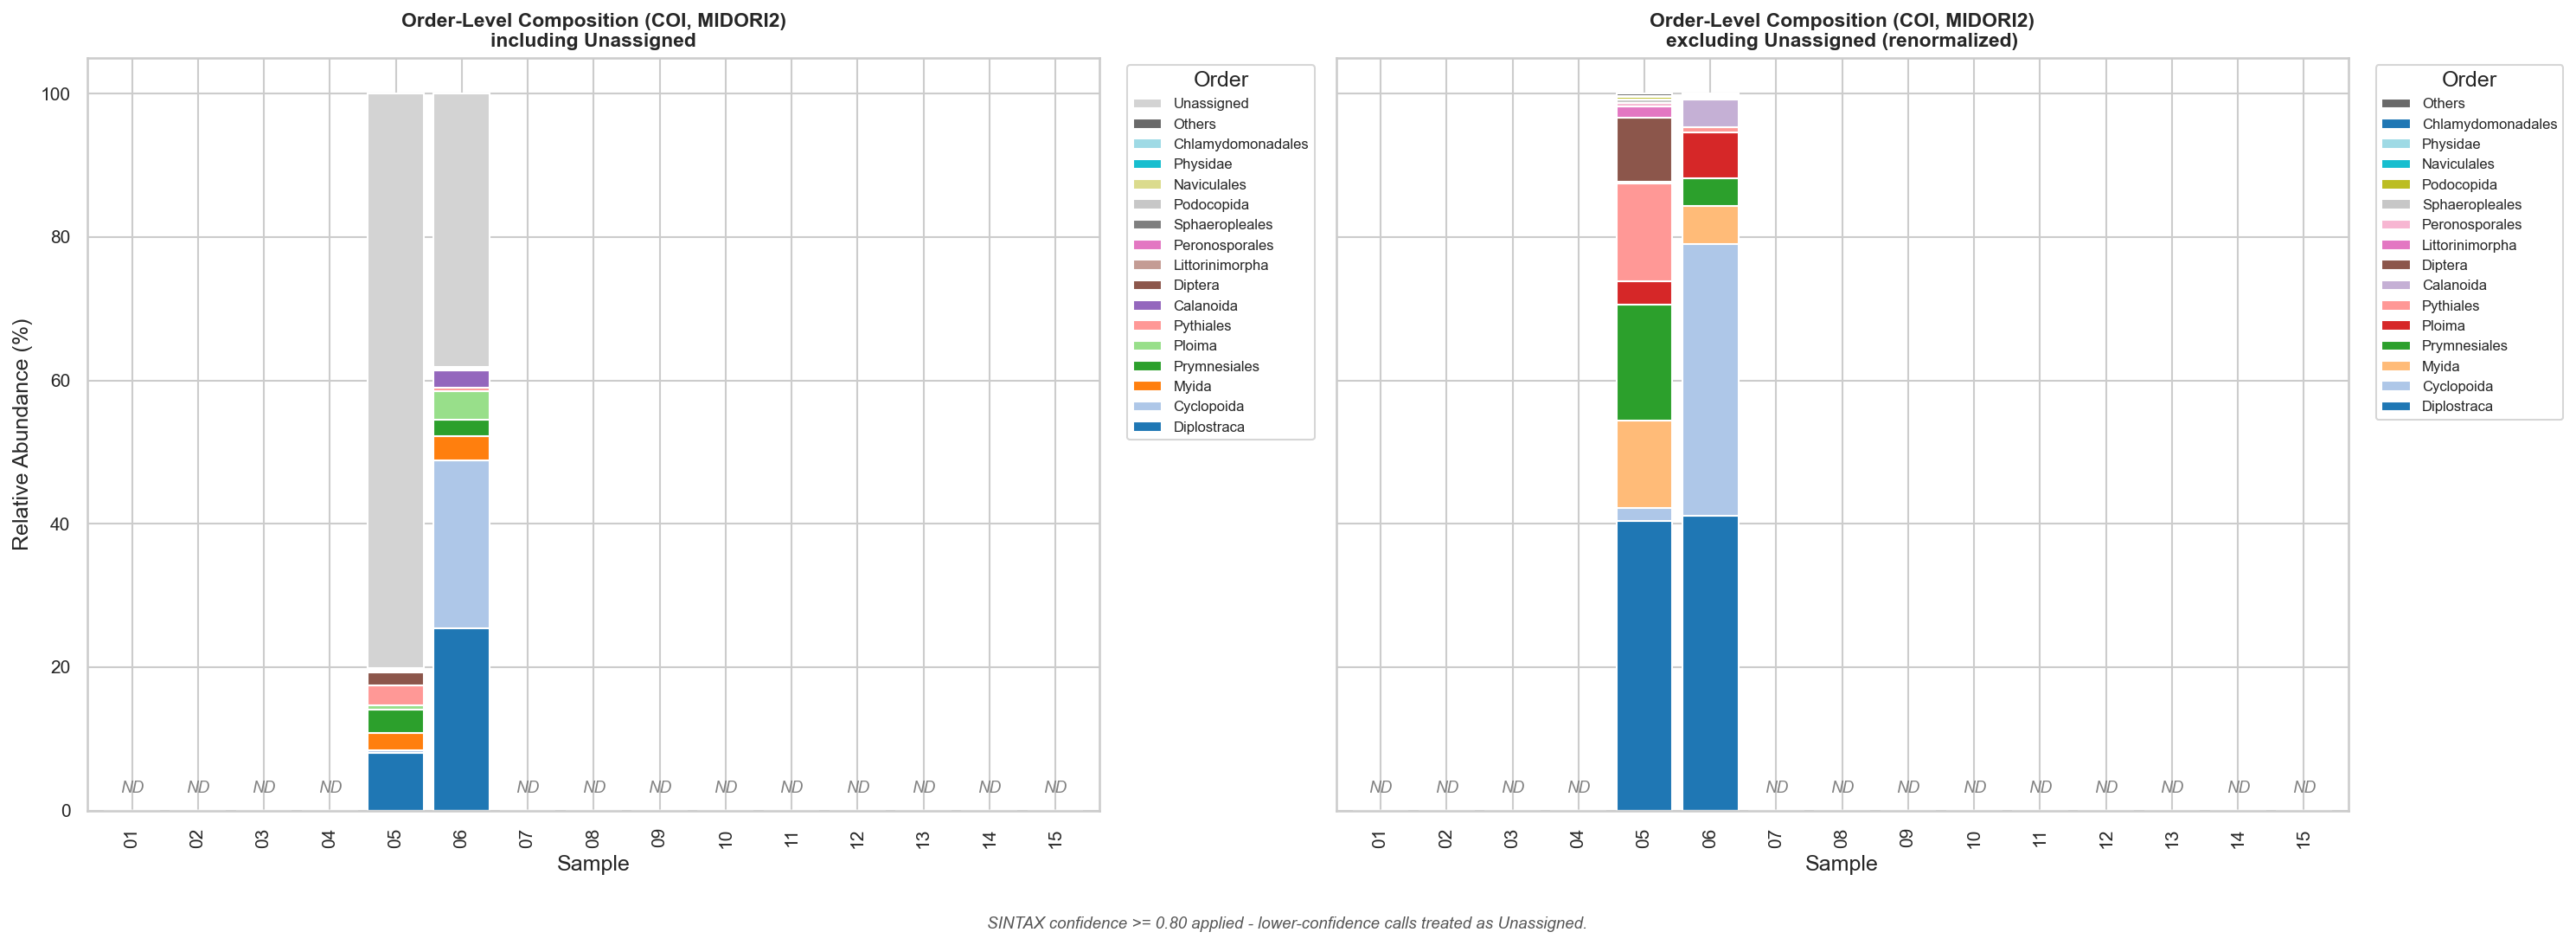

In [21]:
stacked_bar_compare(df_coi, 'Order', prefix_coi, 'COI', sample_cols_coi, top_n=15)

## B.3 Genus-Level Top 20 (COI)
Top genera with high confidence.

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:622: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top['Total'], y=top.index, palette='viridis', ax=ax)


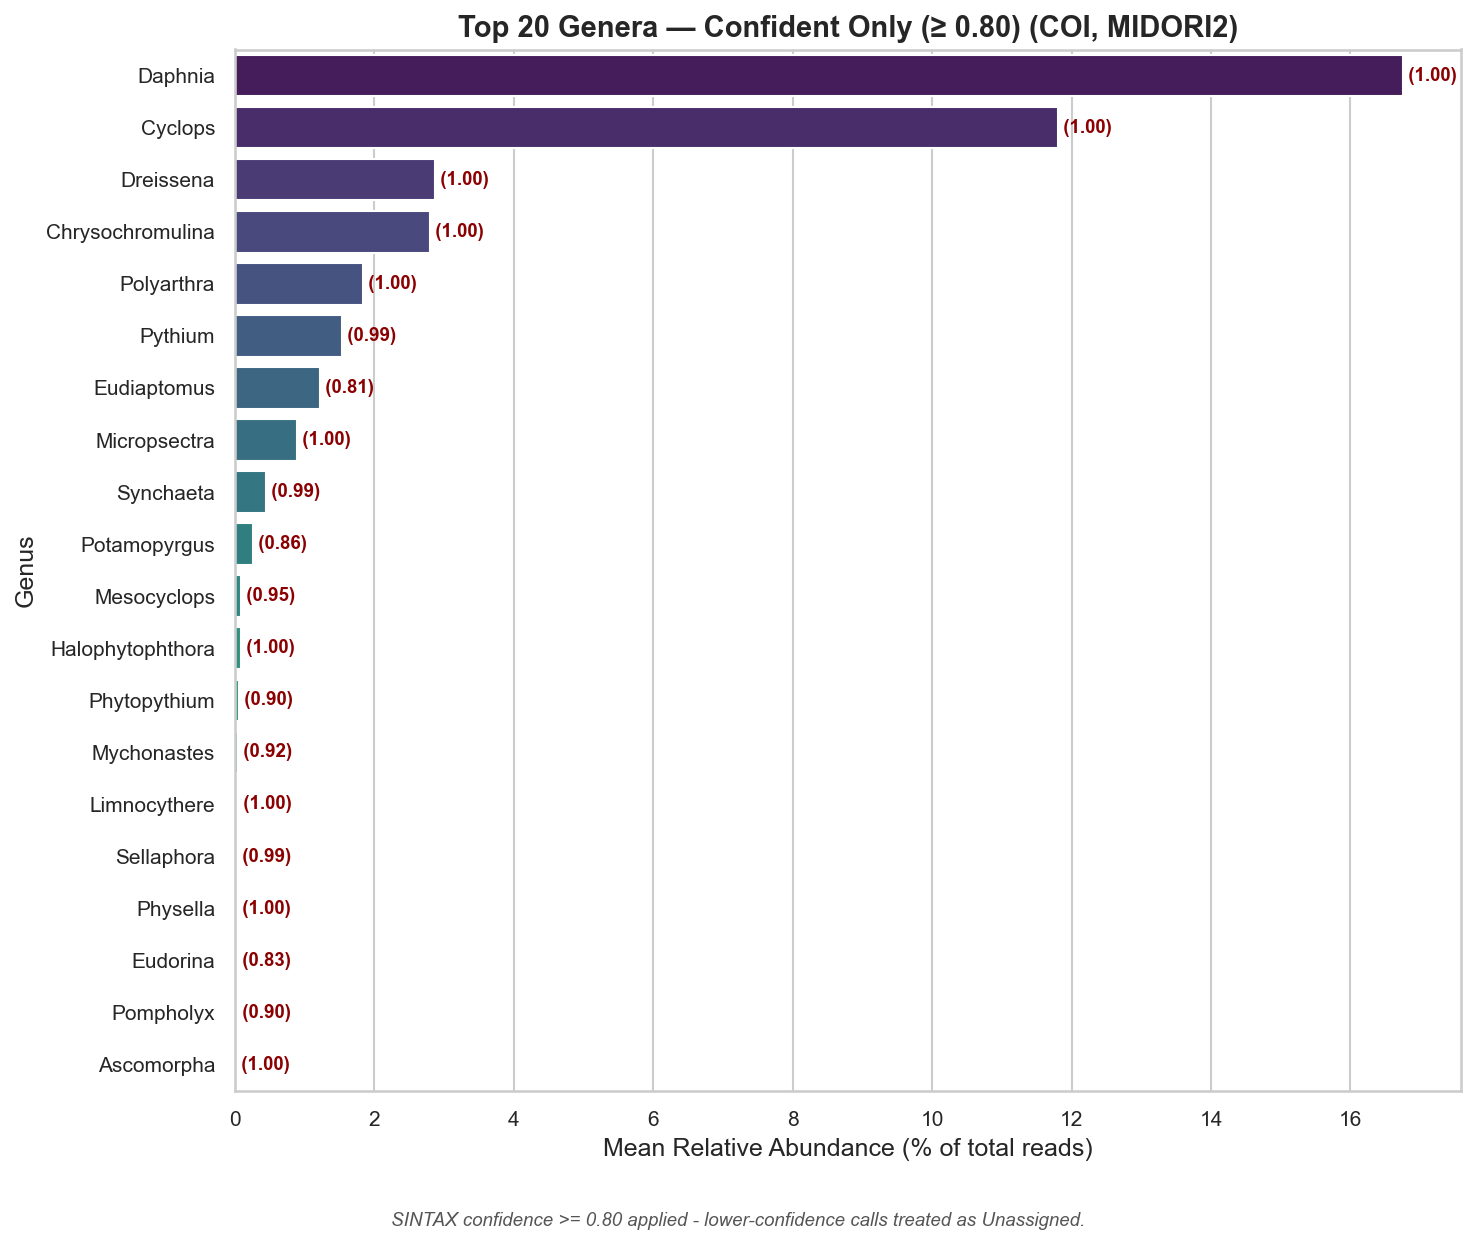

In [22]:
plot_top_genera_confident(df_coi, prefix_coi, 'COI', sample_cols_coi)

### Top 20 Genera by Abundance — All Confidences (COI)
All genus assignments ranked by abundance.

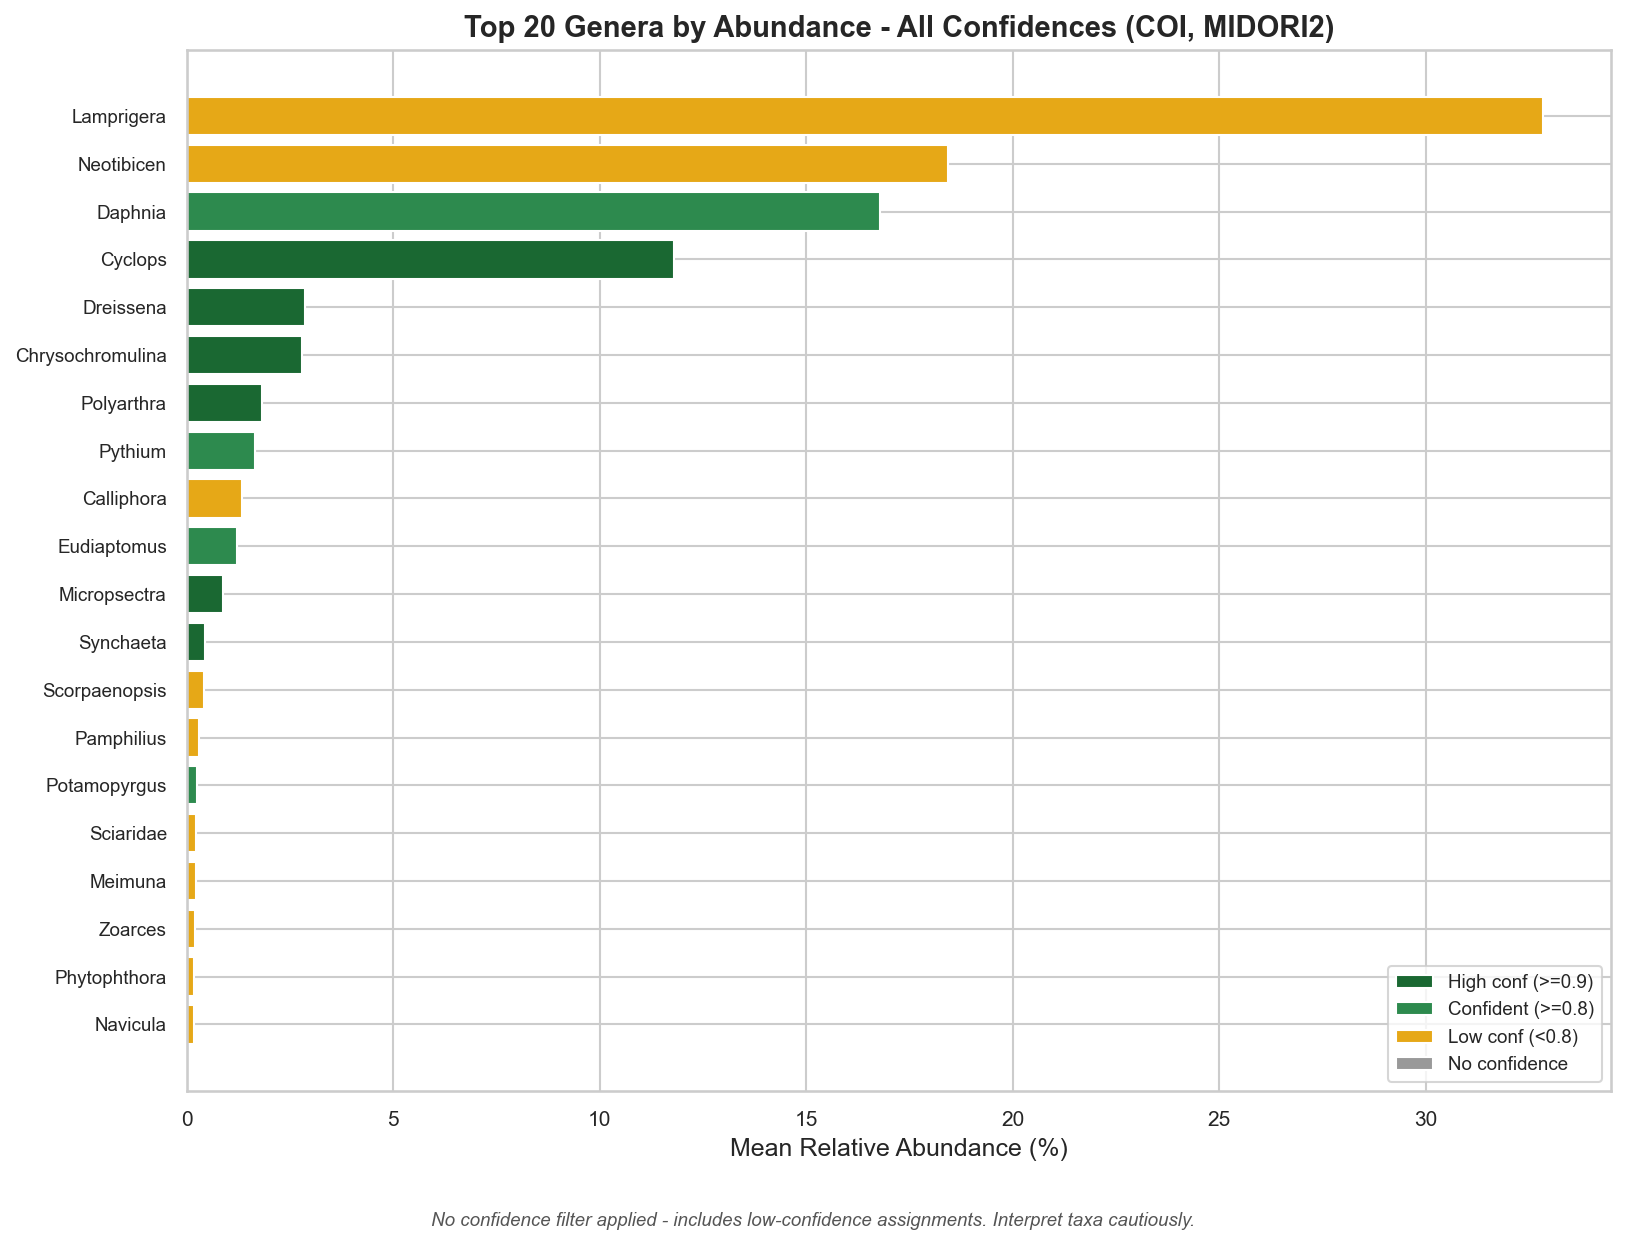

In [23]:
plot_top_genera_all(df_coi, prefix_coi, 'COI', sample_cols_coi)

## B.3b Top 20 Eukaryotic Genera (COI, MIDORI2)
Filtered to Eukaryota only with confidence >= 0.8.

Eukaryota filter: 158/159 OTUs (99.4%)


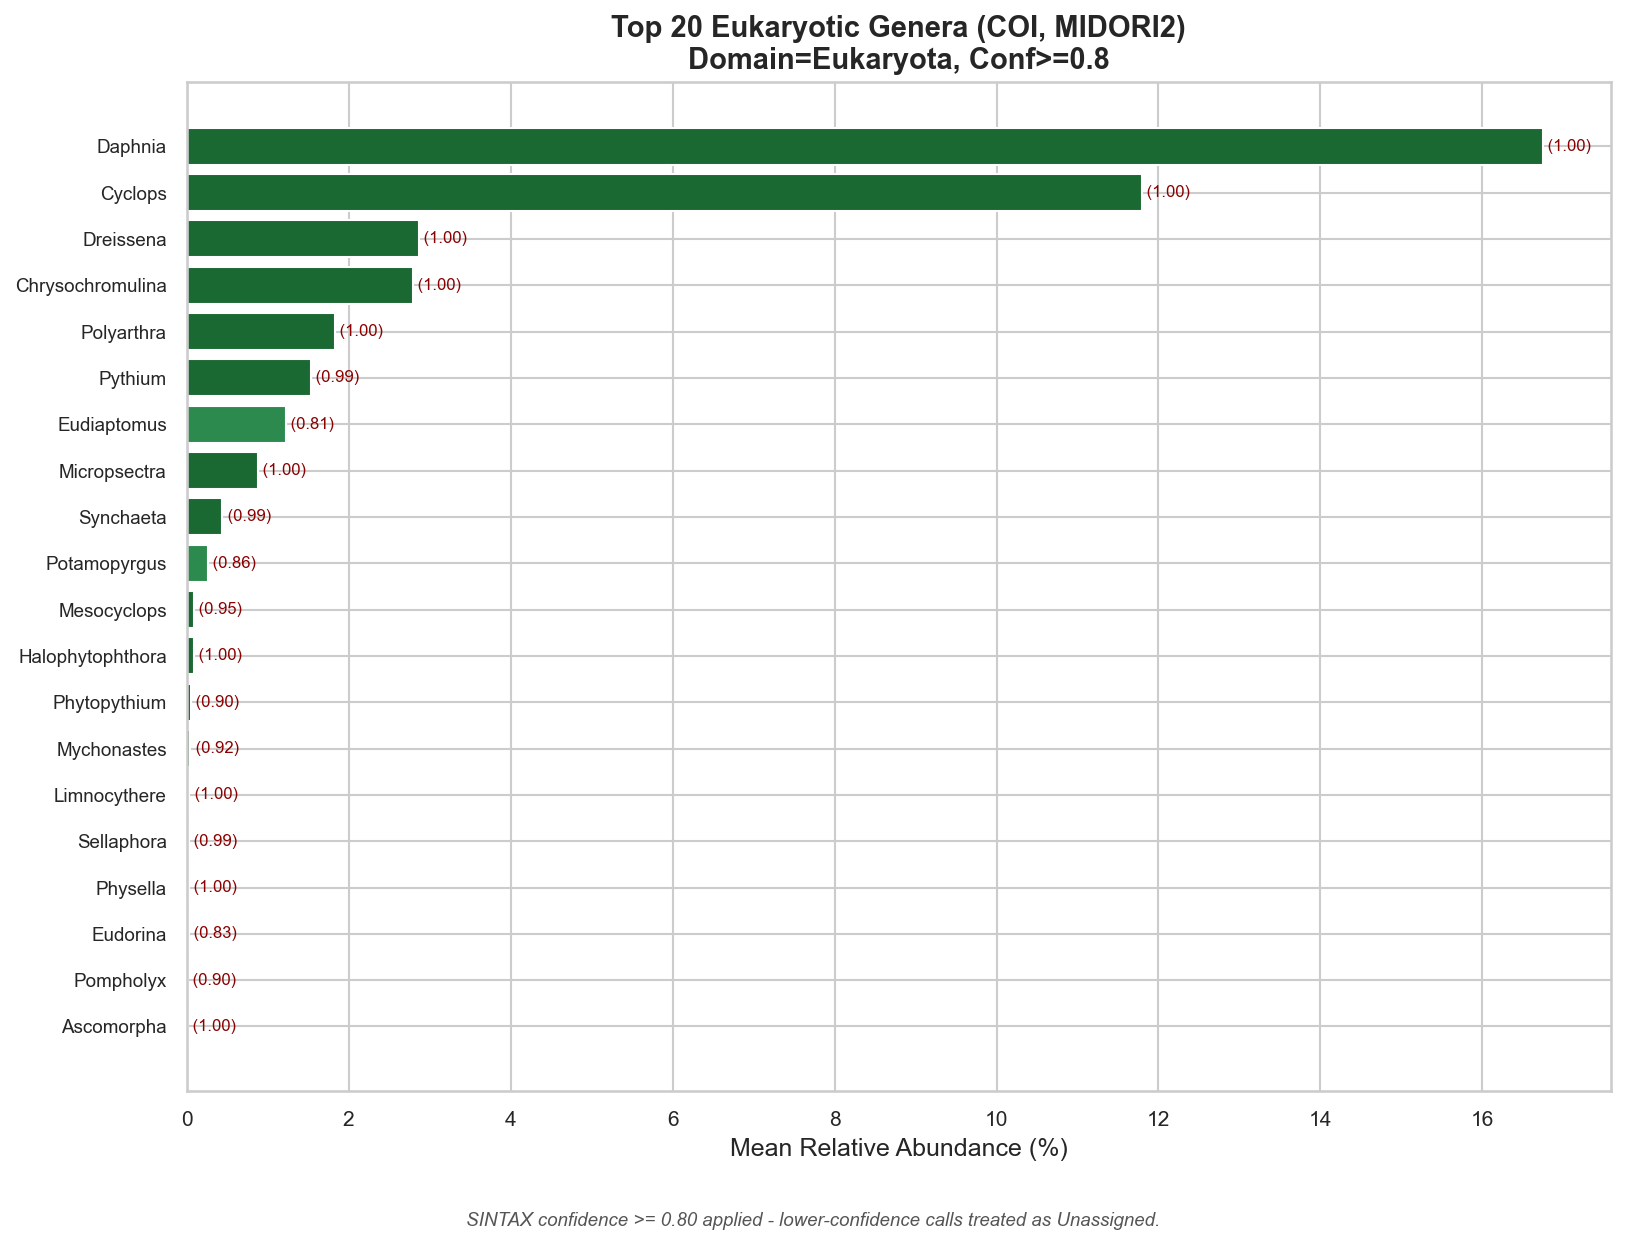

In [24]:
plot_eukaryotic_genera(df_coi, prefix_coi, 'COI', sample_cols_coi)

## BLAST Validation — COI
Top COI OTUs validated against NCBI GenBank.

In [25]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_abundance_COI.txt'), 'COI', 'Abundance')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_abundance_COI.txt'), df_coi_raw, prefix_coi, 'COI')

No BLAST data for COI (Abundance)
No BLAST data for COI table.


In [26]:
plot_blast_hits(str(BASE / 'blast_results/blast_top10_confidence_COI.txt'), 'COI', 'Confidence')
blast_vs_sintax_table(str(BASE / 'blast_results/blast_top10_confidence_COI.txt'), df_coi_raw, prefix_coi, 'COI')

No BLAST data for COI (Confidence)
No BLAST data for COI table.


## Cross-Marker Comparison (18S vs COI)
Genera detected by each marker — overlap reveals complementary coverage.

In [27]:
cross_marker_genus_comparison([
    (df_18s, prefix_18s, '18S'),
    (df_coi, prefix_coi, 'COI')
])

Genera detected by 18S (PR2): 32
Genera detected by COI (MIDORI2): 22

Shared: 1
Only 18S: 31
Only COI: 21

Shared genera: ['Dikerogammarus']
